# Proyecto 3 — Optimización de Pricing en Rutas de Ferry

## Notebook 2 — Análisis exploratorio de pricing y demanda

En este notebook analizamos el dataset generado en el Notebook 1 para entender el comportamiento comercial y operativo de una compañía ficticia de transporte marítimo: **Levante Ferries**.

El análisis se centra en:

- Revenue por ruta.
- Ocupación por ruta.
- Precio medio por ruta.
- Margen por ruta.
- Efecto de la temporada.
- Efecto del día de la semana.
- Efecto de la antelación de compra.
- Comparación con precio de competidor.
- Identificación de oportunidades de pricing.

Este notebook es clave para construir una visión de negocio antes de pasar a elasticidad, modelos predictivos y simulación de escenarios.

In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings

warnings.filterwarnings("ignore")

# Configuración de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Configuración visual
sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# ============================================================
# 2. CONEXIÓN CON GOOGLE DRIVE
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive conectado correctamente.")
except:
    print("No estás ejecutando este notebook en Google Colab o Drive ya está montado.")

Mounted at /content/drive
Google Drive conectado correctamente.


In [3]:
# ============================================================
# 3. DEFINICIÓN DE RUTAS DEL PROYECTO
# ============================================================

base_path = "/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing"

data_path = f"{base_path}/data/processed/ferry_pricing_dataset.csv"
reports_path = f"{base_path}/reports"
images_path = f"{base_path}/images"

os.makedirs(reports_path, exist_ok=True)
os.makedirs(images_path, exist_ok=True)

print("Ruta base del proyecto:")
print(base_path)

print("\nRuta del dataset:")
print(data_path)

Ruta base del proyecto:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing

Ruta del dataset:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/processed/ferry_pricing_dataset.csv


In [4]:
# ============================================================
# 4. CARGA DEL DATASET
# ============================================================

df = pd.read_csv(data_path, parse_dates=["trip_date", "departure_datetime"])

print(f"Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Dataset cargado correctamente.
Filas: 5,475
Columnas: 38


,trip_id,trip_date,departure_datetime,year,month,week,day_of_week,is_weekend,season,high_season_flag,route,origin,destination,route_type,vessel_type,departure_hour,capacity,base_price,avg_ticket_price,competitor_price,price_index_vs_competitor,route_elasticity,days_before_departure,booking_window,weather_score,event_flag,expected_demand,tickets_sold,occupancy_rate,revenue,fixed_operational_cost,variable_cost_per_passenger,total_operational_cost,margin,margin_pct,demand_level,pricing_opportunity,trip_feature
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,8,350,58,44.76,42.02,1.06,-0.85,50,Early,7.90,0,189,189,0.54,"8,459.64",14500,8,16012,"-7,552.36",-0.89,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Early
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,14,350,58,57.35,57.26,1.00,-0.85,34,Medium,7.00,0,160,160,0.46,"9,176.00",14500,8,15780,"-6,604.00",-0.72,Low,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Medium
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,20,350,58,56.78,62.52,0.91,-0.85,9,Short,8.10,0,195,195,0.56,"11,072.10",14500,8,16060,"-4,987.90",-0.45,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Short
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,9,280,72,66.93,66.98,1.00,-0.75,24,Medium,9.30,0,160,160,0.57,"10,708.80",13200,7,14320,"-3,611.20",-0.34,Medium,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,17,280,72,64.16,63.41,1.01,-0.75,36,Medium,6.90,0,131,131,0.47,"8,404.96",13200,7,14117,"-5,712.04",-0.68,Low,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium


In [5]:
# ============================================================
# 5. REVISIÓN INICIAL DEL DATASET
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   trip_id                      5475 non-null   object        
 1   trip_date                    5475 non-null   datetime64[ns]
 2   departure_datetime           5475 non-null   datetime64[ns]
 3   year                         5475 non-null   int64         
 4   month                        5475 non-null   int64         
 5   week                         5475 non-null   int64         
 6   day_of_week                  5475 non-null   object        
 7   is_weekend                   5475 non-null   int64         
 8   season                       5475 non-null   object        
 9   high_season_flag             5475 non-null   int64         
 10  route                        5475 non-null   object        
 11  origin                       5475 non-null 

In [6]:
# Primeras estadísticas numéricas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
trip_date,5475,2025-07-02 00:00:00,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-02 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
departure_datetime,5475,2025-07-02 14:39:59.999999744,2025-01-01 07:00:00,2025-04-02 09:30:00,2025-07-02 14:00:00,2025-10-01 19:30:00,2025-12-31 23:00:00,NaN
year,"5,475.00","2,025.00","2,025.00","2,025.00","2,025.00","2,025.00","2,025.00",0.00
month,"5,475.00",6.53,1.00,4.00,7.00,10.00,12.00,3.45
week,"5,475.00",26.43,1.00,13.00,26.00,39.00,52.00,15.05
is_weekend,"5,475.00",0.43,0.00,0.00,0.00,1.00,1.00,0.49
high_season_flag,"5,475.00",0.17,0.00,0.00,0.00,0.00,1.00,0.38
departure_hour,"5,475.00",14.67,7.00,9.00,14.00,20.00,23.00,5.57
capacity,"5,475.00",459.33,280.00,300.00,350.00,620.00,700.00,165.16
base_price,"5,475.00",61.13,49.00,58.00,62.00,69.00,72.00,7.53


In [7]:
# Comprobación de nulos
null_summary = df.isnull().sum().reset_index()
null_summary.columns = ["column", "missing_values"]
null_summary[null_summary["missing_values"] > 0]

,column,missing_values


In [8]:
# ============================================================
# 6. VARIABLES PRINCIPALES
# ============================================================

main_columns = [
    "trip_id",
    "trip_date",
    "route",
    "season",
    "day_of_week",
    "departure_hour",
    "capacity",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "days_before_departure",
    "booking_window",
    "tickets_sold",
    "occupancy_rate",
    "revenue",
    "total_operational_cost",
    "margin",
    "margin_pct",
    "demand_level",
    "pricing_opportunity"
]

df[main_columns].head(10)

,trip_id,trip_date,route,season,day_of_week,departure_hour,capacity,avg_ticket_price,competitor_price,price_index_vs_competitor,days_before_departure,booking_window,tickets_sold,occupancy_rate,revenue,total_operational_cost,margin,margin_pct,demand_level,pricing_opportunity
0,TRIP_000001,2025-01-01,Denia-Ibiza,Low,Wednesday,8,350,44.76,42.02,1.06,50,Early,189,0.54,"8,459.64",16012,"-7,552.36",-0.89,Medium,Maintain / Monitor
1,TRIP_000002,2025-01-01,Denia-Ibiza,Low,Wednesday,14,350,57.35,57.26,1.00,34,Medium,160,0.46,"9,176.00",15780,"-6,604.00",-0.72,Low,Maintain / Monitor
2,TRIP_000003,2025-01-01,Denia-Ibiza,Low,Wednesday,20,350,56.78,62.52,0.91,9,Short,195,0.56,"11,072.10",16060,"-4,987.90",-0.45,Medium,Maintain / Monitor
3,TRIP_000004,2025-01-01,Denia-Formentera,Low,Wednesday,9,280,66.93,66.98,1.00,24,Medium,160,0.57,"10,708.80",14320,"-3,611.20",-0.34,Medium,Maintain / Monitor
4,TRIP_000005,2025-01-01,Denia-Formentera,Low,Wednesday,17,280,64.16,63.41,1.01,36,Medium,131,0.47,"8,404.96",14117,"-5,712.04",-0.68,Low,Maintain / Monitor
5,TRIP_000006,2025-01-01,Denia-Mallorca,Low,Wednesday,11,520,65.86,65.77,1.00,4,Short,218,0.42,"14,357.48",24680,"-10,322.52",-0.72,Low,Maintain / Monitor
6,TRIP_000007,2025-01-01,Denia-Mallorca,Low,Wednesday,22,520,56.59,51.55,1.10,19,Medium,217,0.42,"12,280.03",24670,"-12,389.97",-1.01,Low,Maintain / Monitor
7,TRIP_000008,2025-01-01,Valencia-Ibiza,Low,Wednesday,10,620,62.86,65.13,0.96,27,Medium,326,0.53,"20,492.36",29086,"-8,593.64",-0.42,Medium,Maintain / Monitor
8,TRIP_000009,2025-01-01,Valencia-Ibiza,Low,Wednesday,23,620,56.68,57.39,0.99,39,Medium,243,0.39,"13,773.24",28173,"-14,399.76",-1.05,Low,Maintain / Monitor
9,TRIP_000010,2025-01-01,Valencia-Mallorca,Low,Wednesday,8,700,48.78,47.63,1.02,23,Medium,496,0.71,"24,194.88",33452,"-9,257.12",-0.38,High,Maintain / Monitor


In [9]:
# ============================================================
# 7. KPIs GENERALES
# ============================================================

total_trips = df["trip_id"].nunique()
total_tickets = df["tickets_sold"].sum()
total_revenue = df["revenue"].sum()
total_cost = df["total_operational_cost"].sum()
total_margin = df["margin"].sum()
avg_occupancy = df["occupancy_rate"].mean()
avg_ticket_price = df["avg_ticket_price"].mean()
avg_margin_pct = df["margin_pct"].mean()

print("KPIs GENERALES")
print("-" * 45)
print(f"Número total de viajes: {total_trips:,.0f}")
print(f"Tickets vendidos: {total_tickets:,.0f}")
print(f"Revenue total: {total_revenue:,.2f} €")
print(f"Coste operativo total: {total_cost:,.2f} €")
print(f"Margen total: {total_margin:,.2f} €")
print(f"Ocupación media: {avg_occupancy:.2%}")
print(f"Precio medio del ticket: {avg_ticket_price:.2f} €")
print(f"Margen porcentual medio: {avg_margin_pct:.2%}")

KPIs GENERALES
---------------------------------------------
Número total de viajes: 5,475
Tickets vendidos: 1,535,436
Revenue total: 102,998,839.77 €
Coste operativo total: 118,535,525.00 €
Margen total: -15,536,685.23 €
Ocupación media: 62.43%
Precio medio del ticket: 65.39 €
Margen porcentual medio: -27.23%


In [10]:
output_csv_path = f"{data_path.replace('.csv', '_for_excel.csv')}"
df.to_csv(output_csv_path, sep=';', decimal=',', index=False, encoding='utf-8')

print(f"DataFrame exportado correctamente a: {output_csv_path}")

DataFrame exportado correctamente a: /content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/processed/ferry_pricing_dataset_for_excel.csv


In [11]:
# ============================================================
# 8. RESUMEN EJECUTIVO POR RUTA
# ============================================================

route_summary = (
    df
    .groupby("route")
    .agg(
        trips=("trip_id", "count"),
        capacity_total=("capacity", "sum"),
        tickets_sold=("tickets_sold", "sum"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        avg_competitor_price=("competitor_price", "mean"),
        avg_price_index=("price_index_vs_competitor", "mean"),
        total_revenue=("revenue", "sum"),
        total_cost=("total_operational_cost", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean"),
        elasticity=("route_elasticity", "mean")
    )
    .reset_index()
)

route_summary["revenue_per_trip"] = route_summary["total_revenue"] / route_summary["trips"]
route_summary["margin_per_trip"] = route_summary["total_margin"] / route_summary["trips"]

route_summary = route_summary.sort_values("total_revenue", ascending=False)

route_summary

,route,trips,capacity_total,tickets_sold,avg_occupancy,avg_ticket_price,avg_competitor_price,avg_price_index,total_revenue,total_cost,total_margin,avg_margin_pct,elasticity,revenue_per_trip,margin_per_trip
5,Valencia-Mallorca,1095,766500,450836,0.59,66.26,65.04,1.02,"30,124,521.77",35522532,"-5,398,010.23",-0.29,-1.05,"27,510.98","-4,929.69"
4,Valencia-Ibiza,730,452600,265104,0.59,74.19,73.00,1.02,"19,932,754.20",21531144,"-1,598,389.80",-0.19,-0.90,"27,305.14","-2,189.58"
1,Denia-Ibiza,1095,383250,278611,0.73,62.08,60.86,1.03,"17,529,547.37",18106388,"-576,840.63",-0.13,-0.85,"16,008.72",-526.80
2,Denia-Mallorca,730,379600,202422,0.53,68.51,67.17,1.03,"14,072,473.81",18449220,"-4,376,746.19",-0.44,-0.95,"19,277.36","-5,995.54"
0,Denia-Formentera,730,204400,138719,0.68,76.70,75.29,1.03,"10,829,083.52",10607033,"222,050.52",-0.08,-0.75,"14,834.36",304.18
3,Ibiza-Mallorca,1095,328500,199744,0.61,52.33,51.40,1.02,"10,510,459.10",14319208,"-3,808,748.90",-0.47,-1.15,"9,598.59","-3,478.31"


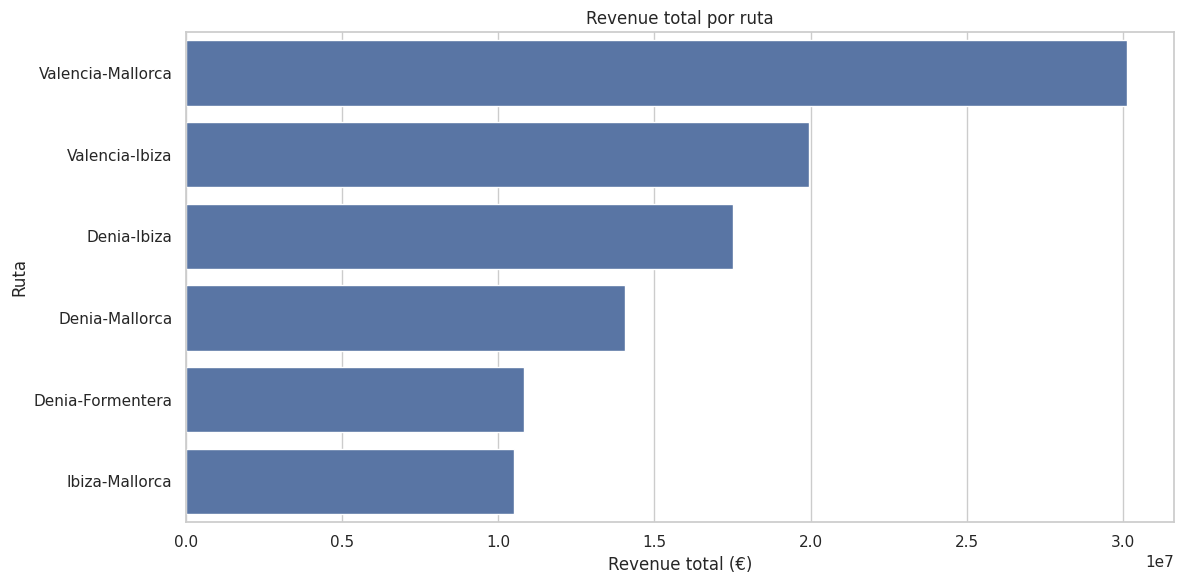

In [12]:
# ============================================================
# 9. RANKING DE RUTAS POR REVENUE
# ============================================================

plt.figure(figsize=(12, 6))

route_revenue = (
    df
    .groupby("route")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=route_revenue.values,
    y=route_revenue.index
)

plt.title("Revenue total por ruta")
plt.xlabel("Revenue total (€)")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/01_revenue_by_route.png", dpi=300, bbox_inches="tight")

plt.show()

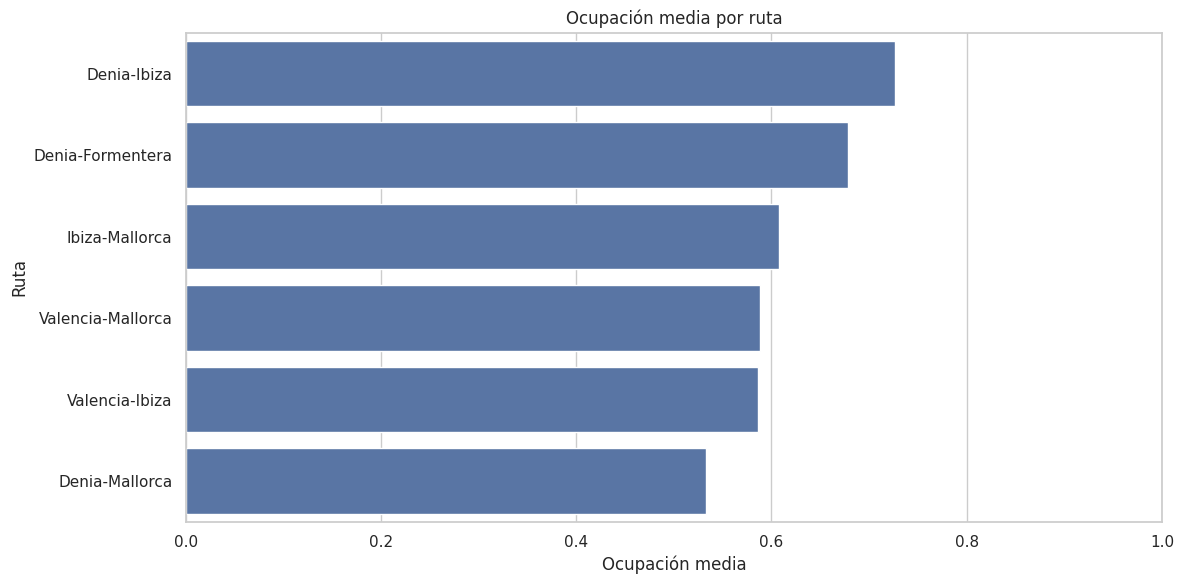

In [13]:
# ============================================================
# 10. OCUPACIÓN MEDIA POR RUTA
# ============================================================

plt.figure(figsize=(12, 6))

route_occupancy = (
    df
    .groupby("route")["occupancy_rate"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=route_occupancy.values,
    y=route_occupancy.index
)

plt.title("Ocupación media por ruta")
plt.xlabel("Ocupación media")
plt.ylabel("Ruta")
plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(f"{images_path}/02_occupancy_by_route.png", dpi=300, bbox_inches="tight")

plt.show()

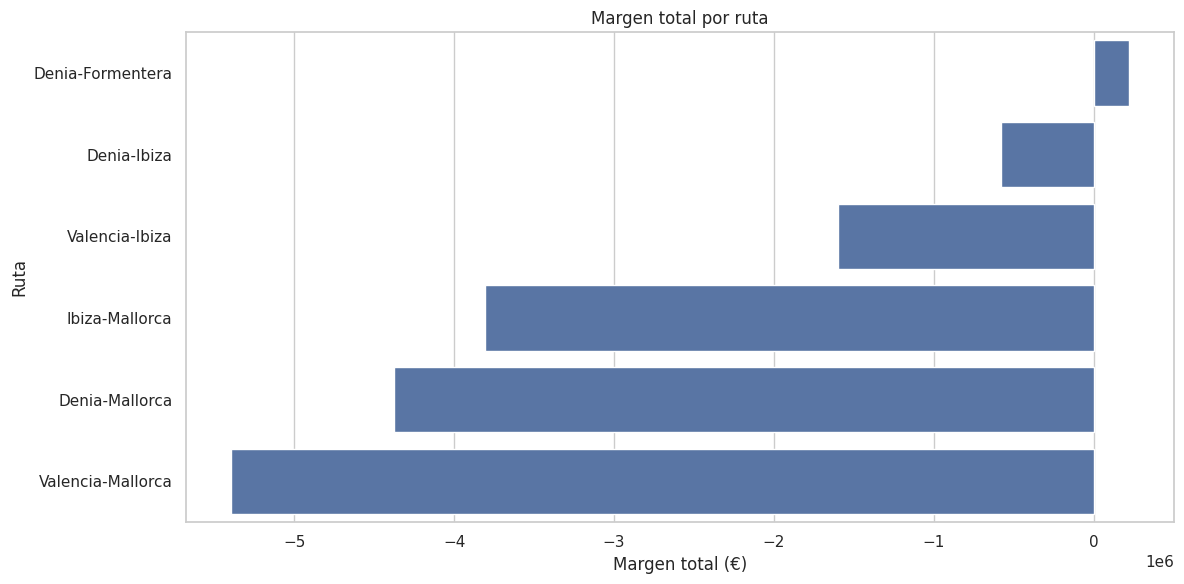

In [14]:
# ============================================================
# 11. MARGEN TOTAL POR RUTA
# ============================================================

plt.figure(figsize=(12, 6))

route_margin = (
    df
    .groupby("route")["margin"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=route_margin.values,
    y=route_margin.index
)

plt.title("Margen total por ruta")
plt.xlabel("Margen total (€)")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/03_margin_by_route.png", dpi=300, bbox_inches="tight")

plt.show()

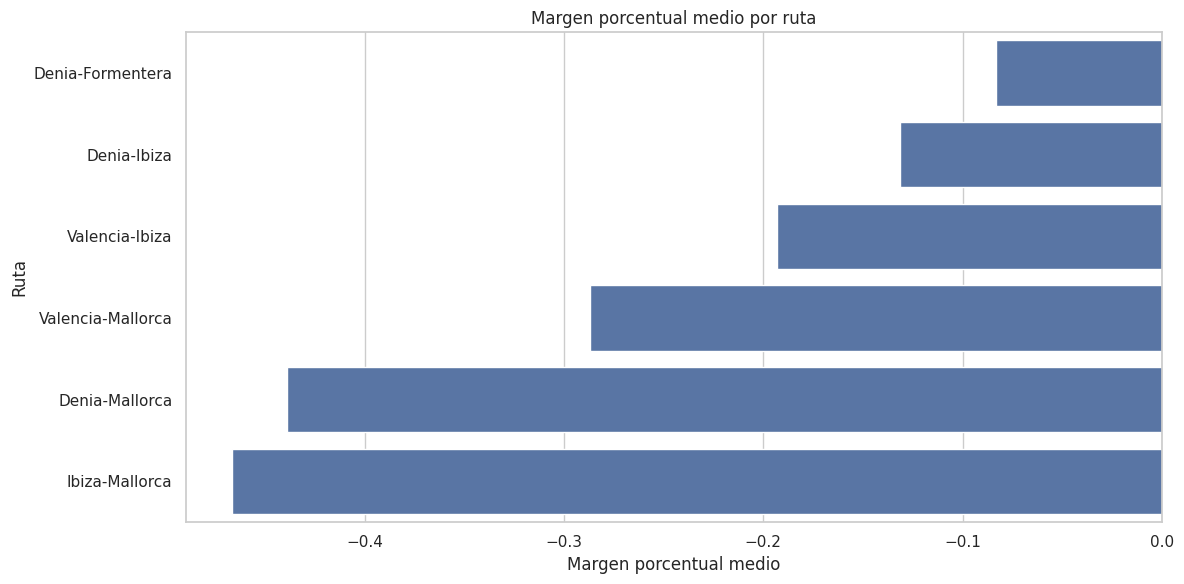

In [15]:
# ============================================================
# 12. MARGEN PORCENTUAL MEDIO POR RUTA
# ============================================================

plt.figure(figsize=(12, 6))

route_margin_pct = (
    df
    .groupby("route")["margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=route_margin_pct.values,
    y=route_margin_pct.index
)

plt.title("Margen porcentual medio por ruta")
plt.xlabel("Margen porcentual medio")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/04_margin_pct_by_route.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
# ============================================================
# 13. TABLA COMPARATIVA DE RUTAS
# ============================================================

route_comparison = route_summary[[
    "route",
    "trips",
    "tickets_sold",
    "avg_occupancy",
    "avg_ticket_price",
    "total_revenue",
    "total_margin",
    "avg_margin_pct",
    "revenue_per_trip",
    "margin_per_trip",
    "elasticity"
]].copy()

route_comparison["avg_occupancy"] = route_comparison["avg_occupancy"].map(lambda x: f"{x:.2%}")
route_comparison["avg_margin_pct"] = route_comparison["avg_margin_pct"].map(lambda x: f"{x:.2%}")
route_comparison["avg_ticket_price"] = route_comparison["avg_ticket_price"].map(lambda x: f"{x:,.2f} €")
route_comparison["total_revenue"] = route_comparison["total_revenue"].map(lambda x: f"{x:,.2f} €")
route_comparison["total_margin"] = route_comparison["total_margin"].map(lambda x: f"{x:,.2f} €")
route_comparison["revenue_per_trip"] = route_comparison["revenue_per_trip"].map(lambda x: f"{x:,.2f} €")
route_comparison["margin_per_trip"] = route_comparison["margin_per_trip"].map(lambda x: f"{x:,.2f} €")

route_comparison

,route,trips,tickets_sold,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,revenue_per_trip,margin_per_trip,elasticity
5,Valencia-Mallorca,1095,450836,58.82%,66.26 €,"30,124,521.77 €","-5,398,010.23 €",-28.68%,"27,510.98 €","-4,929.69 €",-1.05
4,Valencia-Ibiza,730,265104,58.57%,74.19 €,"19,932,754.20 €","-1,598,389.80 €",-19.34%,"27,305.14 €","-2,189.58 €",-0.90
1,Denia-Ibiza,1095,278611,72.70%,62.08 €,"17,529,547.37 €","-576,840.63 €",-13.13%,"16,008.72 €",-526.80 €,-0.85
2,Denia-Mallorca,730,202422,53.32%,68.51 €,"14,072,473.81 €","-4,376,746.19 €",-43.91%,"19,277.36 €","-5,995.54 €",-0.95
0,Denia-Formentera,730,138719,67.87%,76.70 €,"10,829,083.52 €","222,050.52 €",-8.30%,"14,834.36 €",304.18 €,-0.75
3,Ibiza-Mallorca,1095,199744,60.80%,52.33 €,"10,510,459.10 €","-3,808,748.90 €",-46.64%,"9,598.59 €","-3,478.31 €",-1.15


In [17]:
# ============================================================
# 14. RESUMEN POR TEMPORADA
# ============================================================

season_summary = (
    df
    .groupby("season")
    .agg(
        trips=("trip_id", "count"),
        tickets_sold=("tickets_sold", "sum"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

season_order = ["Low", "Shoulder", "High"]
season_summary["season"] = pd.Categorical(season_summary["season"], categories=season_order, ordered=True)
season_summary = season_summary.sort_values("season")

season_summary

,season,trips,tickets_sold,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct
1,Low,2265,552058,0.54,57.19,"31,812,974.26","-16,417,978.74",-0.58
2,Shoulder,2280,681727,0.67,65.37,"45,071,763.53","-4,706,163.47",-0.15
0,High,930,301651,0.72,85.40,"26,114,101.98","5,587,456.98",0.18


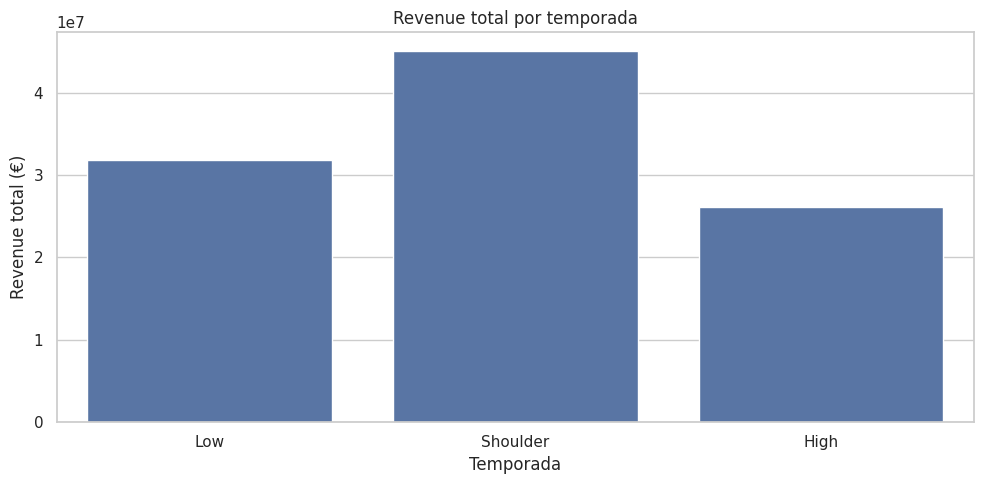

In [18]:
# ============================================================
# 15. REVENUE POR TEMPORADA
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=season_summary,
    x="season",
    y="total_revenue",
    order=season_order
)

plt.title("Revenue total por temporada")
plt.xlabel("Temporada")
plt.ylabel("Revenue total (€)")
plt.tight_layout()

plt.savefig(f"{images_path}/05_revenue_by_season.png", dpi=300, bbox_inches="tight")

plt.show()

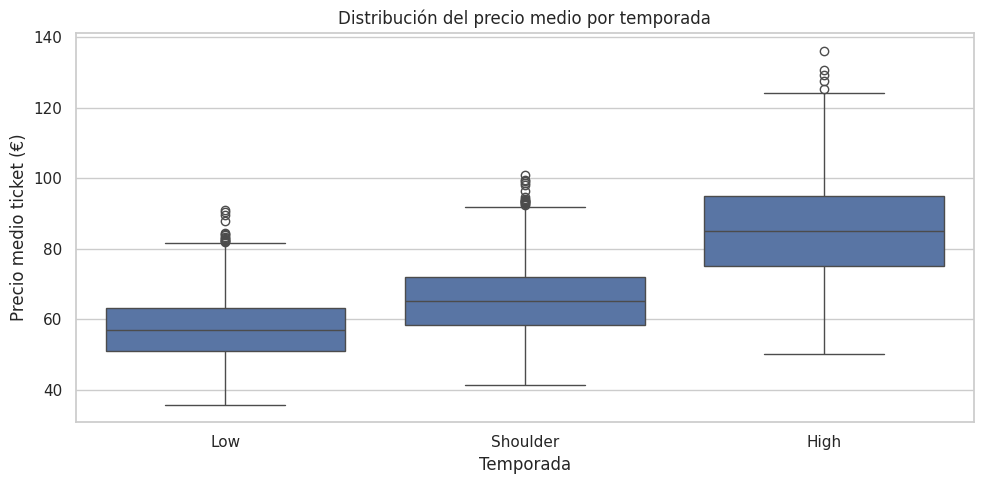

In [19]:
# ============================================================
# 16. PRECIO MEDIO POR TEMPORADA
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="season",
    y="avg_ticket_price",
    order=season_order
)

plt.title("Distribución del precio medio por temporada")
plt.xlabel("Temporada")
plt.ylabel("Precio medio ticket (€)")
plt.tight_layout()

plt.savefig(f"{images_path}/06_price_distribution_by_season.png", dpi=300, bbox_inches="tight")

plt.show()

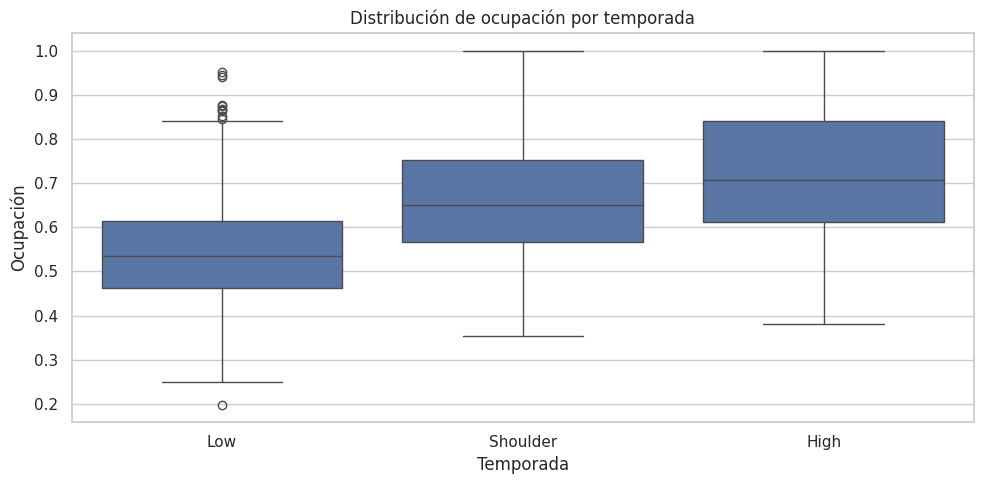

In [20]:
# ============================================================
# 17. OCUPACIÓN POR TEMPORADA
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="season",
    y="occupancy_rate",
    order=season_order
)

plt.title("Distribución de ocupación por temporada")
plt.xlabel("Temporada")
plt.ylabel("Ocupación")
plt.tight_layout()

plt.savefig(f"{images_path}/07_occupancy_distribution_by_season.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
# ============================================================
# 18. RESUMEN MENSUAL
# ============================================================

monthly_summary = (
    df
    .groupby("month")
    .agg(
        trips=("trip_id", "count"),
        tickets_sold=("tickets_sold", "sum"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

monthly_summary

,month,trips,tickets_sold,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct
0,1,465,111619,0.54,57.45,"6,449,517.65","-3,433,198.35",-0.59
1,2,420,102072,0.54,57.02,"5,870,578.03","-3,069,172.97",-0.58
2,3,465,113441,0.54,57.30,"6,565,427.24","-3,335,317.76",-0.57
3,4,450,133782,0.66,65.27,"8,825,459.84","-989,329.16",-0.16
4,5,465,139894,0.67,65.50,"9,270,723.99","-887,738.01",-0.14
5,6,450,136505,0.67,65.23,"8,997,240.21","-846,350.79",-0.14
6,7,465,150322,0.72,85.11,"12,939,782.94","2,679,896.94",0.17
7,8,465,151329,0.73,85.69,"13,174,319.04","2,907,560.04",0.18
8,9,450,132879,0.65,65.23,"8,761,158.39","-1,050,070.61",-0.17
9,10,465,138667,0.66,65.59,"9,217,181.10","-932,674.90",-0.15


In [22]:
import pandas as pd

# ============================================================
# 18. RESUMEN MENSUAL FORMATEADO
# ============================================================

monthly_summary = (
    df
    .groupby("month")
    .agg(
        trips=("trip_id", "count"),
        tickets_sold=("tickets_sold", "sum"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

# Aplicar formato a las columnas numéricas
monthly_summary["avg_occupancy"] = monthly_summary["avg_occupancy"].map(lambda x: f"{x:.2%}")
monthly_summary["avg_ticket_price"] = monthly_summary["avg_ticket_price"].map(lambda x: f"{x:,.2f} €")
monthly_summary["total_revenue"] = monthly_summary["total_revenue"].map(lambda x: f"{x:,.2f} €")
monthly_summary["total_margin"] = monthly_summary["total_margin"].map(lambda x: f"{x:,.2f} €")
monthly_summary["avg_margin_pct"] = monthly_summary["avg_margin_pct"].map(lambda x: f"{x:.2%}")

monthly_summary

,month,trips,tickets_sold,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct
0,1,465,111619,53.57%,57.45 €,"6,449,517.65 €","-3,433,198.35 €",-58.85%
1,2,420,102072,54.12%,57.02 €,"5,870,578.03 €","-3,069,172.97 €",-57.95%
2,3,465,113441,54.43%,57.30 €,"6,565,427.24 €","-3,335,317.76 €",-57.37%
3,4,450,133782,66.38%,65.27 €,"8,825,459.84 €","-989,329.16 €",-15.95%
4,5,465,139894,67.07%,65.50 €,"9,270,723.99 €","-887,738.01 €",-13.72%
5,6,450,136505,67.48%,65.23 €,"8,997,240.21 €","-846,350.79 €",-13.79%
6,7,465,150322,72.11%,85.11 €,"12,939,782.94 €","2,679,896.94 €",17.06%
7,8,465,151329,72.80%,85.69 €,"13,174,319.04 €","2,907,560.04 €",18.11%
8,9,450,132879,65.41%,65.23 €,"8,761,158.39 €","-1,050,070.61 €",-17.18%
9,10,465,138667,66.22%,65.59 €,"9,217,181.10 €","-932,674.90 €",-15.49%


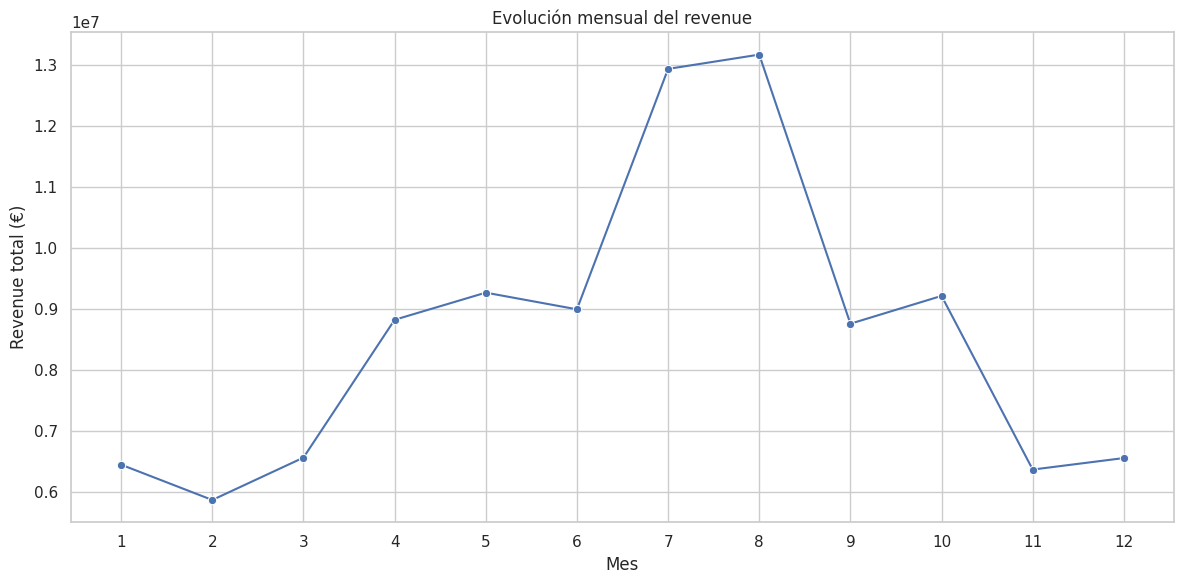

In [23]:
# ============================================================
# 19. EVOLUCIÓN MENSUAL DE REVENUE
# ============================================================

plt.figure(figsize=(12, 6))

# Recalcular el revenue mensual para el gráfico para asegurar valores numéricos
monthly_revenue_for_plot = df.groupby("month")["revenue"].sum().reset_index()

sns.lineplot(
    data=monthly_revenue_for_plot,
    x="month",
    y="revenue", # Usar la columna 'revenue' que ahora es numérica
    marker="o"
)

plt.title("Evolución mensual del revenue")
plt.xlabel("Mes")
plt.ylabel("Revenue total (€)")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig(f"{images_path}/08_monthly_revenue_trend.png", dpi=300, bbox_inches="tight")

plt.show()

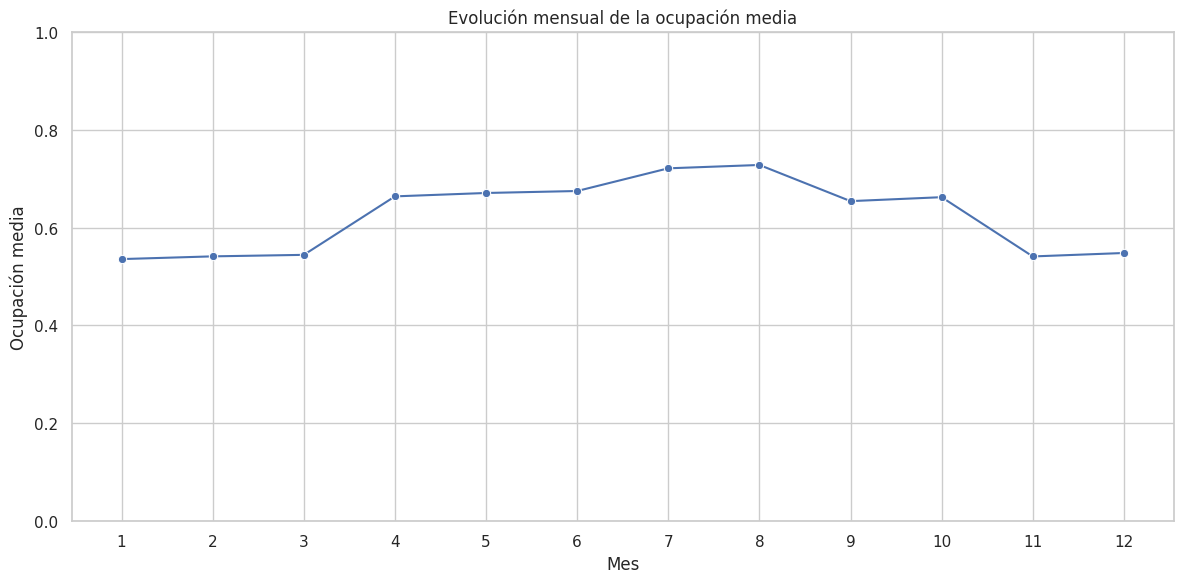

In [24]:
# ============================================================
# 20. EVOLUCIÓN MENSUAL DE OCUPACIÓN
# ============================================================

plt.figure(figsize=(12, 6))

# Recalcular la ocupación media mensual para el gráfico para asegurar valores numéricos
monthly_occupancy_for_plot = df.groupby("month")["occupancy_rate"].mean().reset_index()

sns.lineplot(
    data=monthly_occupancy_for_plot,
    x="month",
    y="occupancy_rate", # Usar la columna 'occupancy_rate' que ahora es numérica
    marker="o"
)

plt.title("Evolución mensual de la ocupación media")
plt.xlabel("Mes")
plt.ylabel("Ocupación media")
plt.xticks(range(1, 13))
plt.ylim(0, 1) # La ocupación va de 0 a 1
plt.tight_layout()

plt.savefig(f"{images_path}/09_monthly_occupancy_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
# ============================================================
# 21. RESUMEN POR DÍA DE LA SEMANA
# ============================================================

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_summary = (
    df
    .groupby("day_of_week")
    .agg(
        trips=("trip_id", "count"),
        tickets_sold=("tickets_sold", "sum"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

day_summary["day_of_week"] = pd.Categorical(day_summary["day_of_week"], categories=day_order, ordered=True)
day_summary = day_summary.sort_values("day_of_week")

day_summary

,day_of_week,trips,tickets_sold,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct
1,Monday,780,193844,0.55,62.81,"12,442,596.38","-4,200,202.62",-0.46
5,Tuesday,780,212944,0.61,63.11,"13,736,606.52","-3,096,106.48",-0.34
6,Wednesday,795,216704,0.61,63.09,"14,008,853.45","-3,140,461.55",-0.34
4,Thursday,780,213337,0.61,63.08,"13,748,529.80","-3,087,381.20",-0.34
0,Friday,780,233186,0.67,68.89,"16,405,593.66","-622,807.34",-0.13
2,Saturday,780,231387,0.66,68.61,"16,292,629.10","-718,317.90",-0.15
3,Sunday,780,234034,0.67,68.16,"16,364,030.86","-671,408.14",-0.14


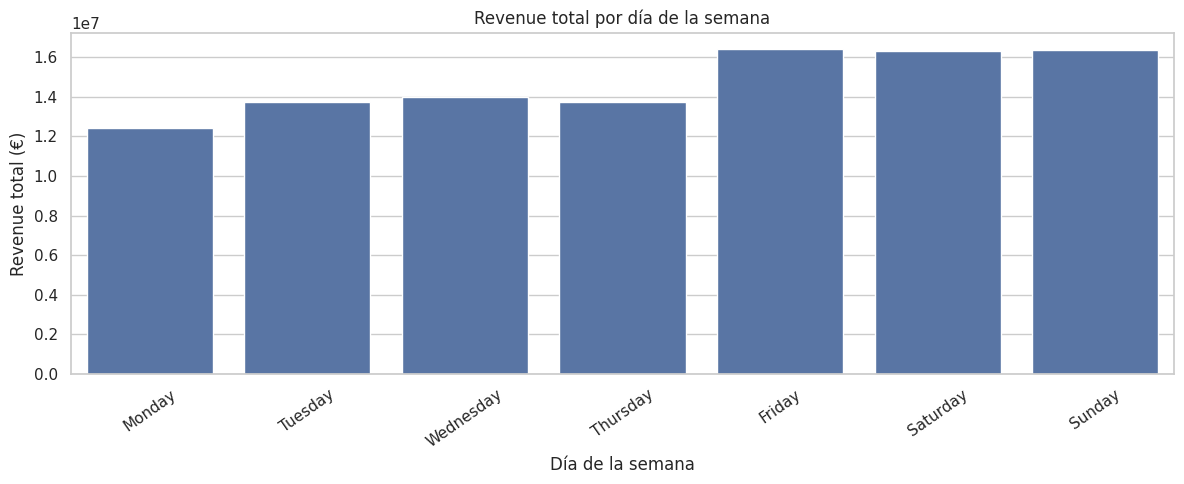

In [26]:
# ============================================================
# 22. REVENUE POR DÍA DE LA SEMANA
# ============================================================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=day_summary,
    x="day_of_week",
    y="total_revenue",
    order=day_order
)

plt.title("Revenue total por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Revenue total (€)")
plt.xticks(rotation=35)
plt.tight_layout()

plt.savefig(f"{images_path}/10_revenue_by_day_of_week.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
# ============================================================
# 23. OCUPACIÓN POR HORA DE SALIDA
# ============================================================

hour_summary = (
    df
    .groupby("departure_hour")
    .agg(
        trips=("trip_id", "count"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
    .sort_values("departure_hour")
)

hour_summary

,departure_hour,trips,avg_occupancy,avg_ticket_price,total_revenue,avg_margin_pct
0,7,365,0.62,51.99,"3,558,492.99",-0.44
1,8,730,0.69,64.36,"16,949,798.01",-0.14
2,9,365,0.71,76.28,"5,595,338.86",-0.05
3,10,365,0.65,74.31,"11,089,581.63",-0.08
4,11,365,0.57,68.72,"7,608,290.33",-0.34
5,13,365,0.57,52.68,"3,284,707.00",-0.55
6,14,365,0.68,61.57,"5,402,445.39",-0.22
7,16,365,0.60,66.65,"10,277,282.96",-0.25
8,17,365,0.65,77.12,"5,233,744.66",-0.12
9,19,365,0.64,52.33,"3,667,259.11",-0.41


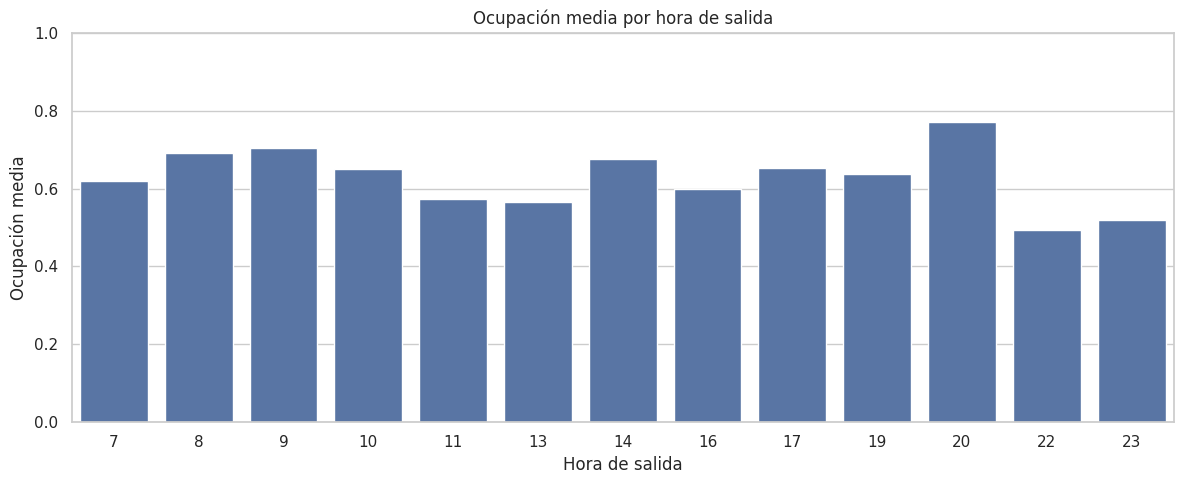

In [28]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=hour_summary,
    x="departure_hour",
    y="avg_occupancy"
)

plt.title("Ocupación media por hora de salida")
plt.xlabel("Hora de salida")
plt.ylabel("Ocupación media")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(f"{images_path}/11_occupancy_by_departure_hour.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
# ============================================================
# 24. RESUMEN POR VENTANA DE RESERVA
# ============================================================

booking_order = ["Early", "Medium", "Short", "Last minute"]

booking_summary = (
    df
    .groupby("booking_window")
    .agg(
        trips=("trip_id", "count"),
        avg_days_before_departure=("days_before_departure", "mean"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

booking_summary["booking_window"] = pd.Categorical(
    booking_summary["booking_window"],
    categories=booking_order,
    ordered=True
)

booking_summary = booking_summary.sort_values("booking_window")
booking_summary["avg_occupancy"] = booking_summary["avg_occupancy"].map(lambda x: f"{x:.2%}")
booking_summary["avg_ticket_price"] = booking_summary["avg_ticket_price"].map(lambda x: f"{x:,.2f} €")
booking_summary["total_revenue"] = booking_summary["total_revenue"].map(lambda x: f"{x:,.2f} €")
booking_summary["total_margin"] = booking_summary["total_margin"].map(lambda x: f"{x:,.2f} €")
booking_summary["avg_margin_pct"] = booking_summary["avg_margin_pct"].map(lambda x: f"{x:.2%}")

booking_summary

,booking_window,trips,avg_days_before_departure,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct
0,Early,419,55.01,68.41%,59.03 €,"7,885,190.29 €","-1,359,695.71 €",-29.40%
2,Medium,3675,26.03,63.36%,64.15 €,"69,202,486.18 €","-10,878,986.82 €",-27.65%
3,Short,1349,10.37,58.26%,70.39 €,"25,316,175.42 €","-3,261,550.58 €",-25.53%
1,Last minute,32,2.38,53.68%,79.19 €,"594,987.88 €","-36,452.12 €",-21.48%


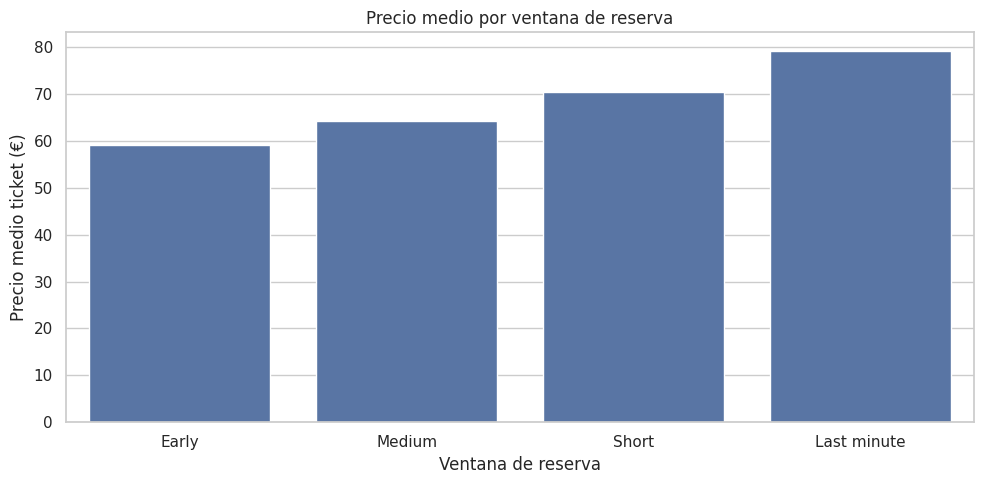

In [30]:
# ============================================================
# 25. PRECIO MEDIO POR VENTANA DE RESERVA
# ============================================================

# Recalculate booking_summary to ensure avg_ticket_price is numeric for sorting and plotting
booking_summary_numeric = (
    df
    .groupby("booking_window")
    .agg(
        trips=("trip_id", "count"),
        avg_days_before_departure=("days_before_departure", "mean"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

booking_summary_numeric["booking_window"] = pd.Categorical(
    booking_summary_numeric["booking_window"],
    categories=booking_order,
    ordered=True
)

# Sort by avg_ticket_price in ascending order
booking_summary_numeric = booking_summary_numeric.sort_values("avg_ticket_price", ascending=True)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=booking_summary_numeric,
    x="booking_window",
    y="avg_ticket_price",
    order=booking_summary_numeric["booking_window"]
)

plt.title("Precio medio por ventana de reserva")
plt.xlabel("Ventana de reserva")
plt.ylabel("Precio medio ticket (€)")
# Remove custom y-ticks to allow seaborn/matplotlib to determine coherent ones
# plt.yticks(booking_summary["avg_ticket_price"].apply(lambda x: float(x.replace(' €', '').replace(',', ''))))
plt.tight_layout()

plt.savefig(f"{images_path}/12_price_by_booking_window.png", dpi=300, bbox_inches="tight")

plt.show()

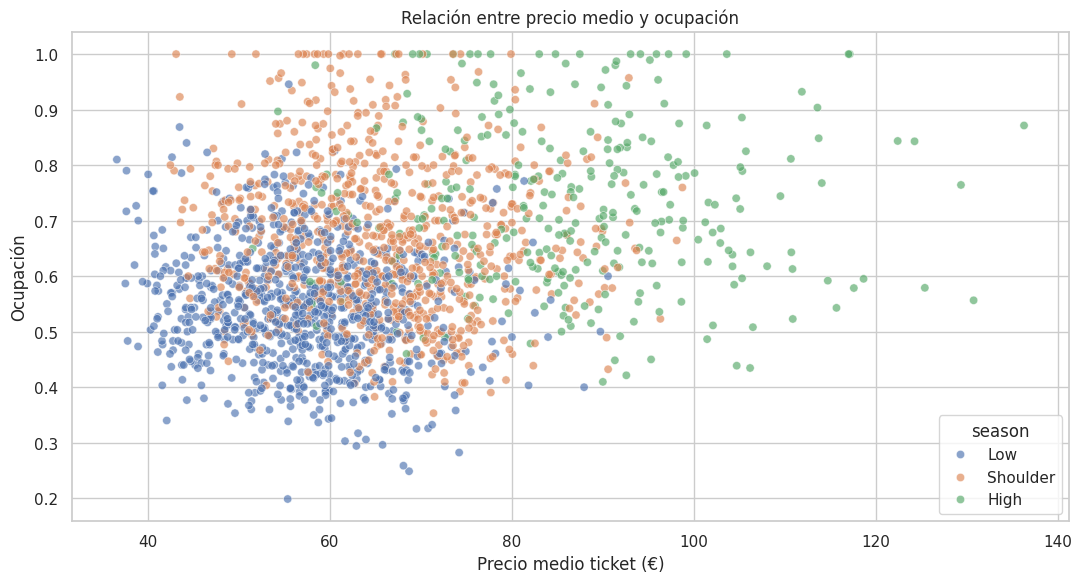

In [31]:
# ============================================================
# 26. RELACIÓN ENTRE PRECIO Y OCUPACIÓN
# ============================================================

sample_df = df.sample(min(2000, len(df)), random_state=42)

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=sample_df,
    x="avg_ticket_price",
    y="occupancy_rate",
    hue="season",
    alpha=0.65
)

plt.title("Relación entre precio medio y ocupación")
plt.xlabel("Precio medio ticket (€)")
plt.ylabel("Ocupación")
plt.tight_layout()

plt.savefig(f"{images_path}/13_price_vs_occupancy.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 1200x700 with 0 Axes>

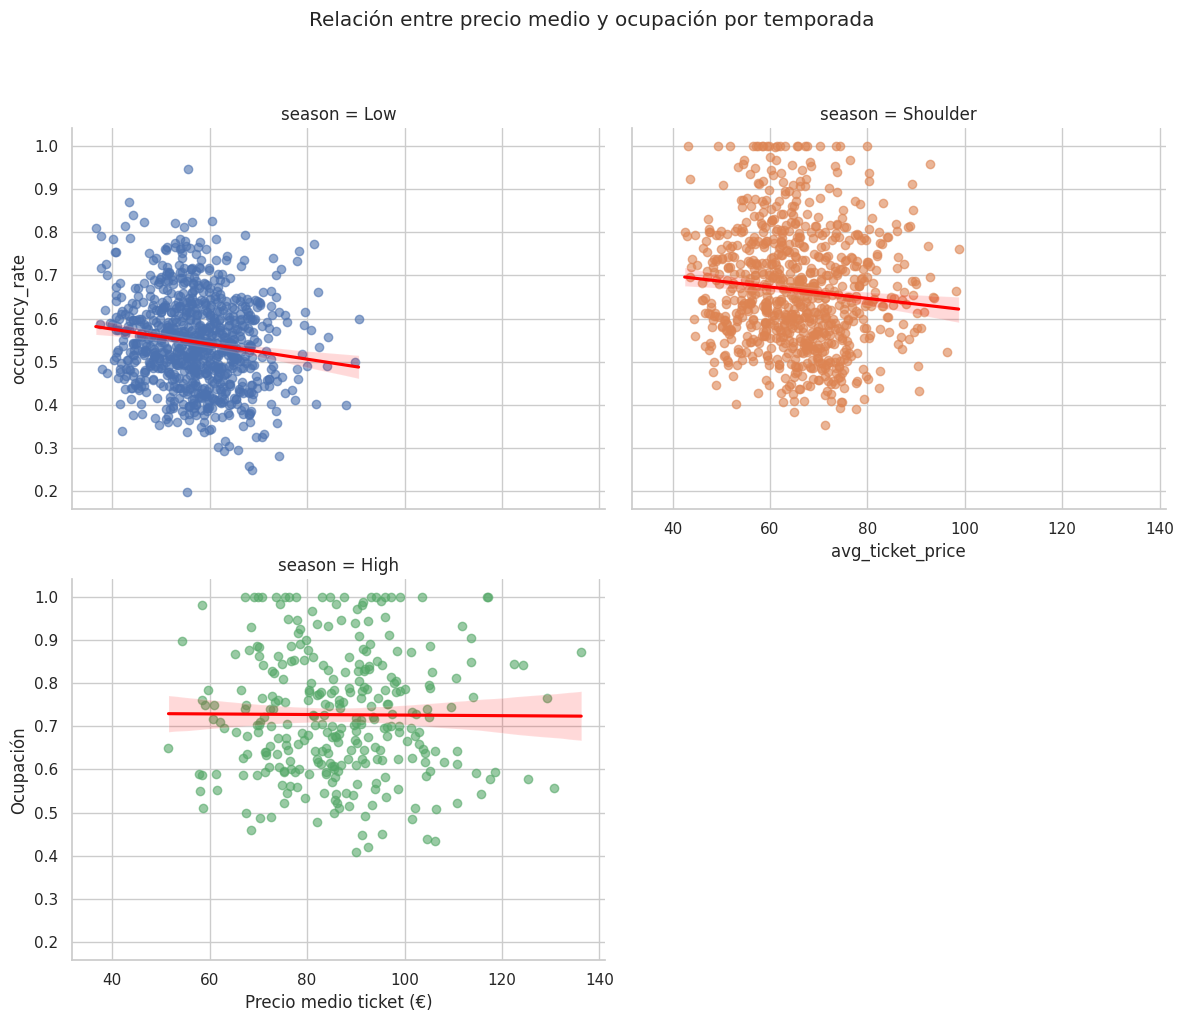

In [32]:
# ============================================================
# 27. RELACIÓN ENTRE PRECIO Y OCUPACIÓN POR TEMPORADA (con línea de regresión)
# ============================================================

# Using lmplot to show the relationship between average ticket price and occupancy rate
# separated by season, including a regression line.
# Using the same sample_df for consistency and performance.

plt.figure(figsize=(12, 7))

sns.lmplot(
    data=sample_df,
    x="avg_ticket_price",
    y="occupancy_rate",
    hue="season",
    col="season", # Create separate plots for each season
    col_wrap=2, # Wrap columns after 2 plots
    height=5, # Height of each facet
    aspect=1.2, # Aspect ratio of each facet
    scatter_kws={'alpha':0.6}, # Transparency for scatter points
    line_kws={'color':'red'} # Color for regression line
)

plt.suptitle("Relación entre precio medio y ocupación por temporada", y=1.02) # Adjust suptitle position
plt.xlabel("Precio medio ticket (€)")
plt.ylabel("Ocupación")
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap

plt.savefig(f"{images_path}/14_price_vs_occupancy_season_lmplot.png", dpi=300, bbox_inches="tight")

plt.show()

Este lmplot ayuda a visualizar la relación lineal (o la ausencia de ella) entre avg_ticket_price (precio medio del billete) y occupancy_rate (tasa de ocupación) para cada temporada. La línea roja representa el ajuste de la regresión lineal para esa temporada en particular. Esto puede ayudarnos a identificar si los precios más altos generalmente conducen a una menor ocupación, y si esta tendencia varía significativamente entre las diferentes temporadas.

Por ejemplo, podrías observar:

En Temporada Alta, incluso con precios medios de billete más altos, la ocupación podría seguir siendo alta, o la pendiente de la línea de regresión podría ser menos negativa, lo que indica una menor sensibilidad al precio.
En Temporada Baja, podría haber una correlación negativa más fuerte, lo que significaría que los precios más altos podrían llevar a una caída más significativa en la ocupación.
Este tipo de análisis proporciona una visión más clara y cuantificable de la elasticidad de los precios en diferentes períodos de demanda.

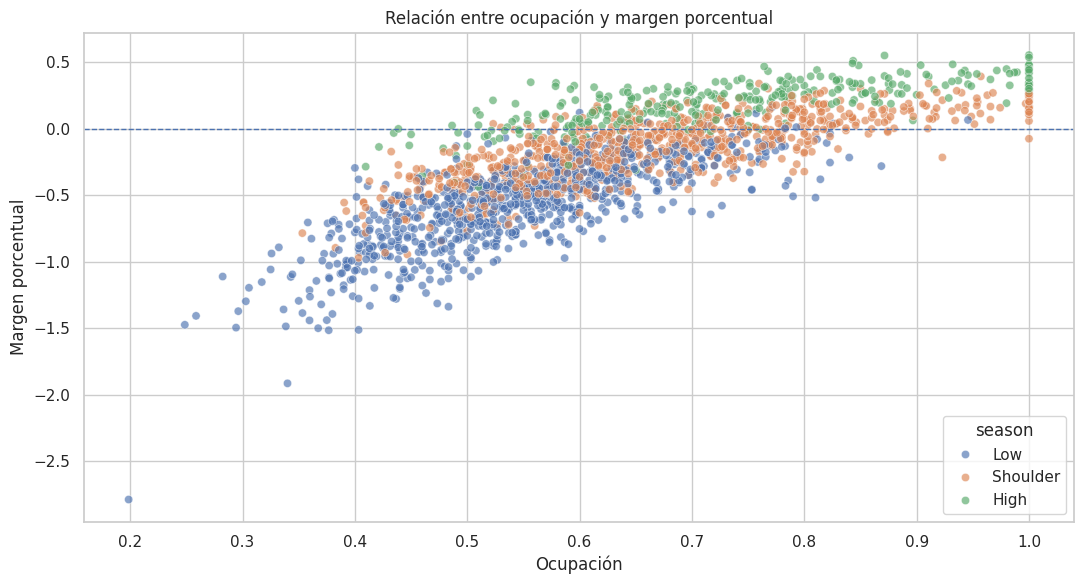

In [33]:
# ============================================================
# 27. RELACIÓN ENTRE OCUPACIÓN Y MARGEN PORCENTUAL
# ============================================================

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=sample_df,
    x="occupancy_rate",
    y="margin_pct",
    hue="season",
    alpha=0.65
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Relación entre ocupación y margen porcentual")
plt.xlabel("Ocupación")
plt.ylabel("Margen porcentual")
plt.tight_layout()

plt.savefig(f"{images_path}/14_occupancy_vs_margin_pct.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 1200x700 with 0 Axes>

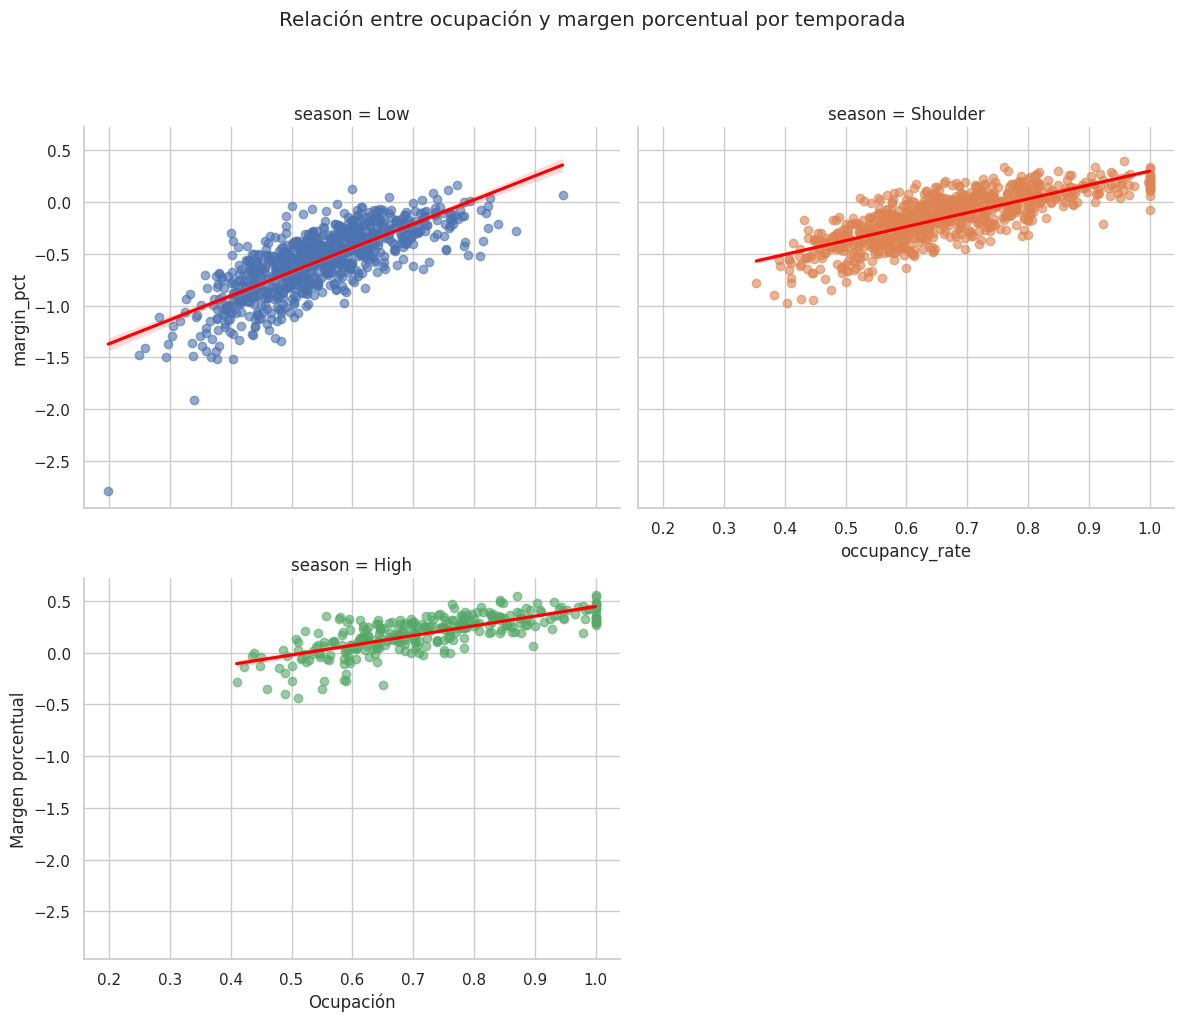

In [34]:
# ============================================================
# 28. RELACIÓN ENTRE OCUPACIÓN Y MARGEN PORCENTUAL POR TEMPORADA (con línea de regresión)
# ============================================================

# Using lmplot to show the relationship between occupancy rate and margin percentage
# separated by season, including a regression line.
# Using the same sample_df for consistency and performance.

plt.figure(figsize=(12, 7))

sns.lmplot(
    data=sample_df,
    x="occupancy_rate",
    y="margin_pct",
    hue="season",
    col="season", # Create separate plots for each season
    col_wrap=2, # Wrap columns after 2 plots
    height=5, # Height of each facet
    aspect=1.2, # Aspect ratio of each facet
    scatter_kws={'alpha':0.6}, # Transparency for scatter points
    line_kws={'color':'red'} # Color for regression line
)

plt.suptitle("Relación entre ocupación y margen porcentual por temporada", y=1.02) # Adjust suptitle position
plt.xlabel("Ocupación")
plt.ylabel("Margen porcentual")
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap

plt.savefig(f"{images_path}/15_occupancy_vs_margin_pct_season_lmplot.png", dpi=300, bbox_inches="tight")

plt.show()

Este gráfico nos permite ver cómo la tasa de ocupación influye en el margen porcentual en cada temporada. Las líneas de regresión rojas muestran la tendencia general para cada período:

Temporada Baja (Low): La línea de regresión tiene una pendiente positiva pronunciada, lo que indica que en temporada baja, un aumento en la ocupación se traduce en una mejora significativa del margen porcentual. Sin embargo, muchos puntos están por debajo del 0% de margen, sugiriendo que muchos viajes en esta temporada operan con pérdidas si la ocupación no es lo suficientemente alta.
Temporada Media (Shoulder): Similar a la temporada baja, también observamos una relación positiva entre ocupación y margen, aunque la pendiente puede ser ligeramente menos pronunciada. Hay una mayor concentración de viajes con márgenes positivos a medida que aumenta la ocupación.
Temporada Alta (High): En temporada alta, la relación sigue siendo positiva, pero la pendiente de la línea de regresión parece más suave. Esto podría indicar que, aunque la ocupación alta generalmente genera buenos márgenes, la elasticidad del margen respecto a la ocupación es menor, o que ya se opera cerca de la capacidad máxima con buenos márgenes independientemente de pequeñas variaciones en la ocupación. También se observa que la mayoría de los viajes en esta temporada tienen un margen positivo, incluso con ocupaciones moderadas.

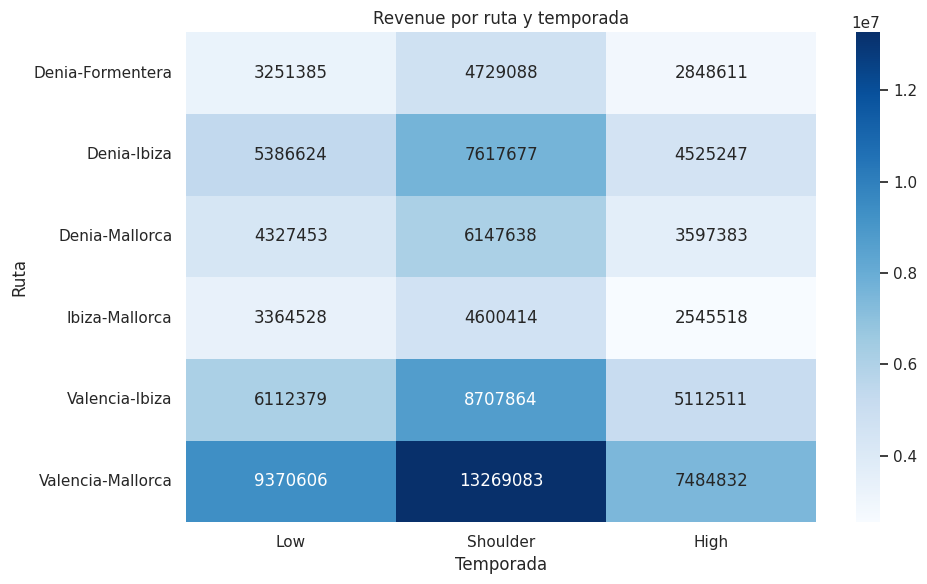

In [35]:
# ============================================================
# 28. HEATMAP RUTA-TEMPORADA: REVENUE
# ============================================================

route_season_revenue = (
    df
    .groupby(["route", "season"])["revenue"]
    .sum()
    .reset_index()
)

revenue_pivot = route_season_revenue.pivot(
    index="route",
    columns="season",
    values="revenue"
)

revenue_pivot = revenue_pivot[season_order]

plt.figure(figsize=(10, 6))

sns.heatmap(
    revenue_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Revenue por ruta y temporada")
plt.xlabel("Temporada")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/15_heatmap_route_season_revenue.png", dpi=300, bbox_inches="tight")

plt.show()


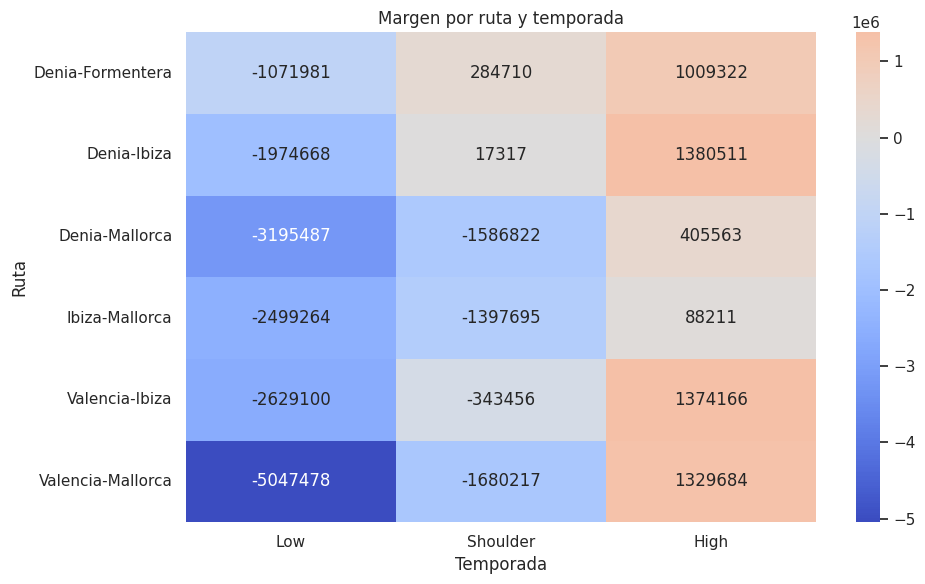

In [36]:
# ============================================================
# 29. HEATMAP RUTA-TEMPORADA: MARGIN
# ============================================================

route_season_margin = (
    df
    .groupby(["route", "season"])["margin"]
    .sum()
    .reset_index()
)

margin_pivot = route_season_margin.pivot(
    index="route",
    columns="season",
    values="margin"
)

margin_pivot = margin_pivot[season_order]

plt.figure(figsize=(10, 6))

sns.heatmap(
    margin_pivot,
    annot=True,
    fmt=".0f",
    cmap="coolwarm", # Use a diverging colormap for margin (positive/negative)
    center=0 # Center the colormap at 0 for clear distinction between profit/loss
)

plt.title("Margen por ruta y temporada")
plt.xlabel("Temporada")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/16_heatmap_route_season_margin.png", dpi=300, bbox_inches="tight")

plt.show()

Este mapa de calor muestra el margen total generado por cada ruta en cada temporada. Utilizo un esquema de color `coolwarm` centrado en 0 para que sea fácil distinguir entre las rutas y temporadas que generan **ganancias (rojo)** y las que generan **pérdidas (azul)**. Los valores anotados son el margen total en euros.

Este gráfico es muy útil para:

- Identificar combinaciones de ruta-temporada que son consistentemente rentables o deficitarias.
- Analizar el impacto de la estacionalidad en la rentabilidad de rutas específicas.
- Guiar decisiones de pricing y asignación de recursos para maximizar el margen general.

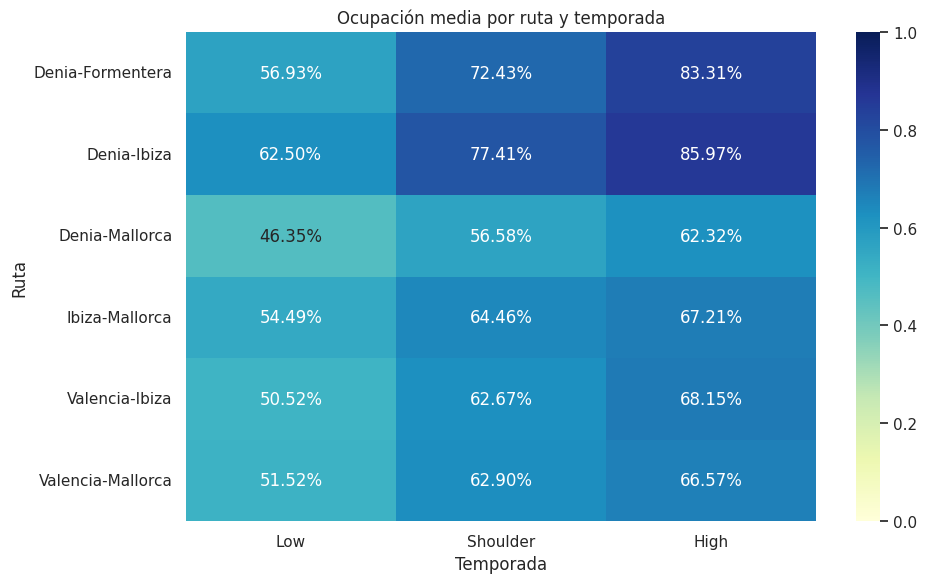

In [37]:
# ============================================================
# 29. HEATMAP RUTA-TEMPORADA: OCUPACIÓN
# ============================================================

route_season_occupancy = (
    df
    .groupby(["route", "season"])["occupancy_rate"]
    .mean()
    .reset_index()
)

occupancy_pivot = route_season_occupancy.pivot(
    index="route",
    columns="season",
    values="occupancy_rate"
)

occupancy_pivot = occupancy_pivot[season_order]

plt.figure(figsize=(10, 6))

sns.heatmap(
    occupancy_pivot,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Ocupación media por ruta y temporada")
plt.xlabel("Temporada")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/16_heatmap_route_season_occupancy.png", dpi=300, bbox_inches="tight")

plt.show()

In [38]:
# ============================================================
# 30. COMPARACIÓN CON PRECIO DE COMPETIDOR
# ============================================================

competitor_summary = (
    df
    .groupby("route")
    .agg(
        avg_ticket_price=("avg_ticket_price", "mean"),
        avg_competitor_price=("competitor_price", "mean"),
        avg_price_index=("price_index_vs_competitor", "mean"),
        avg_occupancy=("occupancy_rate", "mean"),
        total_revenue=("revenue", "sum")
    )
    .reset_index()
)

competitor_summary["price_gap_pct"] = (
    (competitor_summary["avg_ticket_price"] / competitor_summary["avg_competitor_price"]) - 1
)

competitor_summary = competitor_summary.sort_values("avg_price_index", ascending=False)

competitor_summary

,route,avg_ticket_price,avg_competitor_price,avg_price_index,avg_occupancy,total_revenue,price_gap_pct
2,Denia-Mallorca,68.51,67.17,1.03,0.53,"14,072,473.81",0.02
1,Denia-Ibiza,62.08,60.86,1.03,0.73,"17,529,547.37",0.02
0,Denia-Formentera,76.70,75.29,1.03,0.68,"10,829,083.52",0.02
5,Valencia-Mallorca,66.26,65.04,1.02,0.59,"30,124,521.77",0.02
3,Ibiza-Mallorca,52.33,51.40,1.02,0.61,"10,510,459.10",0.02
4,Valencia-Ibiza,74.19,73.00,1.02,0.59,"19,932,754.20",0.02


In [39]:
# ============================================================
# 32. DISTRIBUCIÓN DE OPORTUNIDADES DE PRICING
# ============================================================

pricing_opportunity_summary = (
    df["pricing_opportunity"]
    .value_counts()
    .reset_index()
)

pricing_opportunity_summary.columns = ["pricing_opportunity", "number_of_trips"]

pricing_opportunity_summary

,pricing_opportunity,number_of_trips
0,Maintain / Monitor,4305
1,Promotion opportunity,795
2,Potential price increase,203
3,High demand but low margin,172


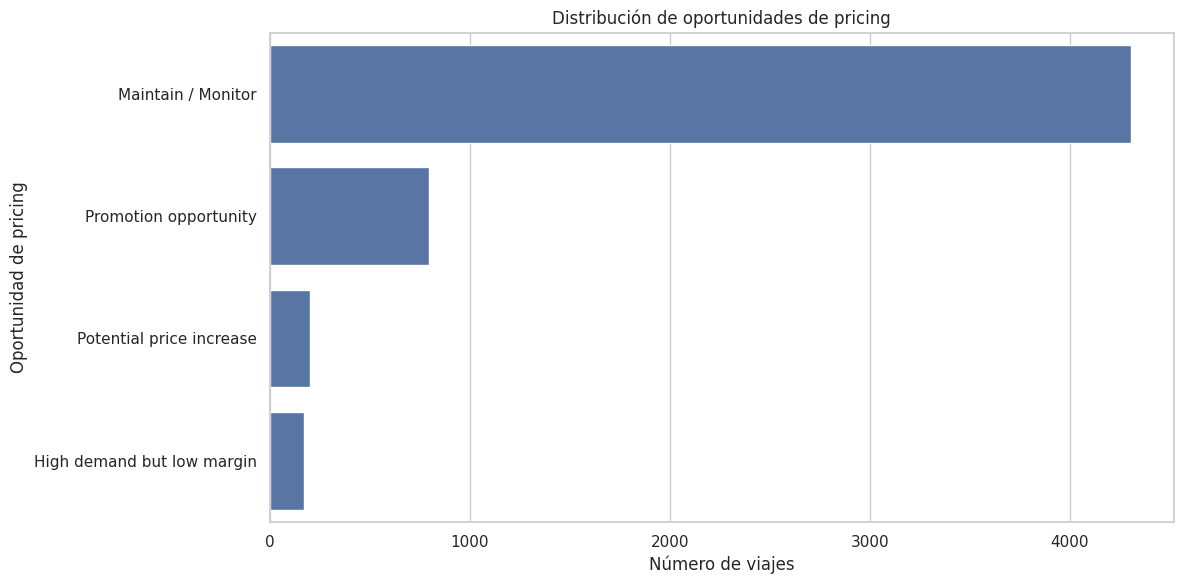

In [40]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pricing_opportunity_summary,
    x="number_of_trips",
    y="pricing_opportunity"
)

plt.title("Distribución de oportunidades de pricing")
plt.xlabel("Número de viajes")
plt.ylabel("Oportunidad de pricing")
plt.tight_layout()

plt.savefig(f"{images_path}/18_pricing_opportunity_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [41]:
# ============================================================
# 33. OPORTUNIDADES DE PRICING POR RUTA
# ============================================================

pricing_route_table = pd.crosstab(
    df["route"],
    df["pricing_opportunity"]
)

pricing_route_table

pricing_opportunity,High demand but low margin,Maintain / Monitor,Potential price increase,Promotion opportunity
route,,,,
Denia-Formentera,14,637,79,0
Denia-Ibiza,112,876,107,0
Denia-Mallorca,0,727,3,0
Ibiza-Mallorca,24,712,0,359
Valencia-Ibiza,6,710,14,0
Valencia-Mallorca,16,643,0,436


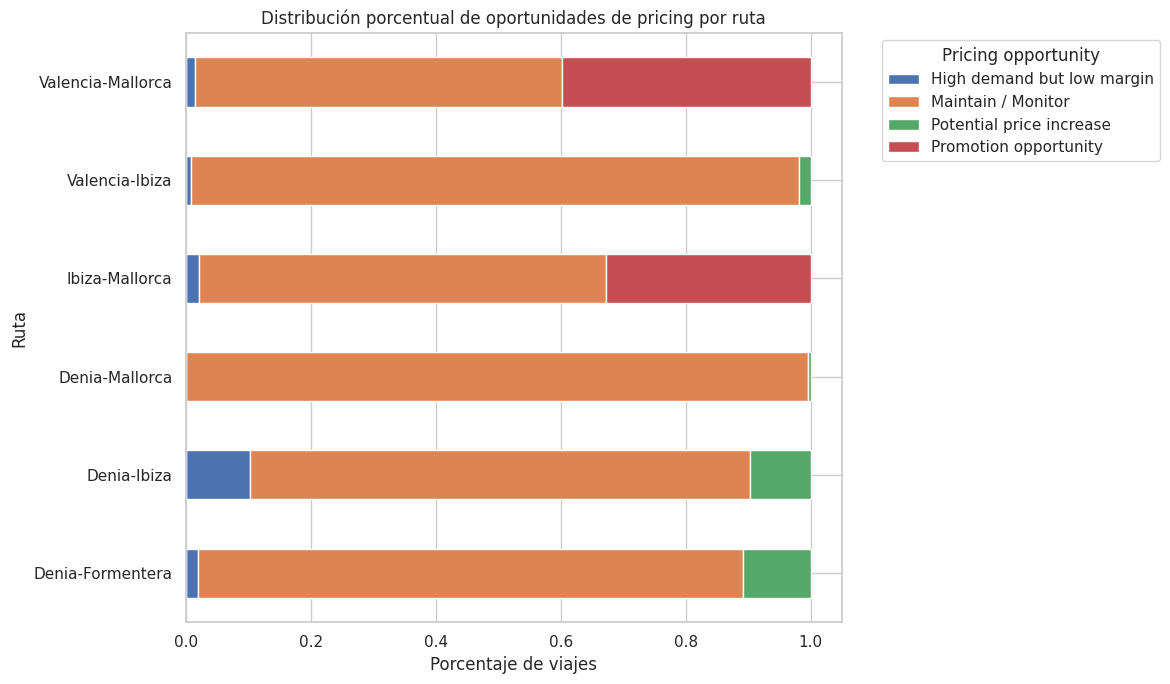

In [42]:
pricing_route_pct = pd.crosstab(
    df["route"],
    df["pricing_opportunity"],
    normalize="index"
)

pricing_route_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Distribución porcentual de oportunidades de pricing por ruta")
plt.xlabel("Porcentaje de viajes")
plt.ylabel("Ruta")
plt.legend(title="Pricing opportunity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(f"{images_path}/19_pricing_opportunity_by_route.png", dpi=300, bbox_inches="tight")

plt.show()


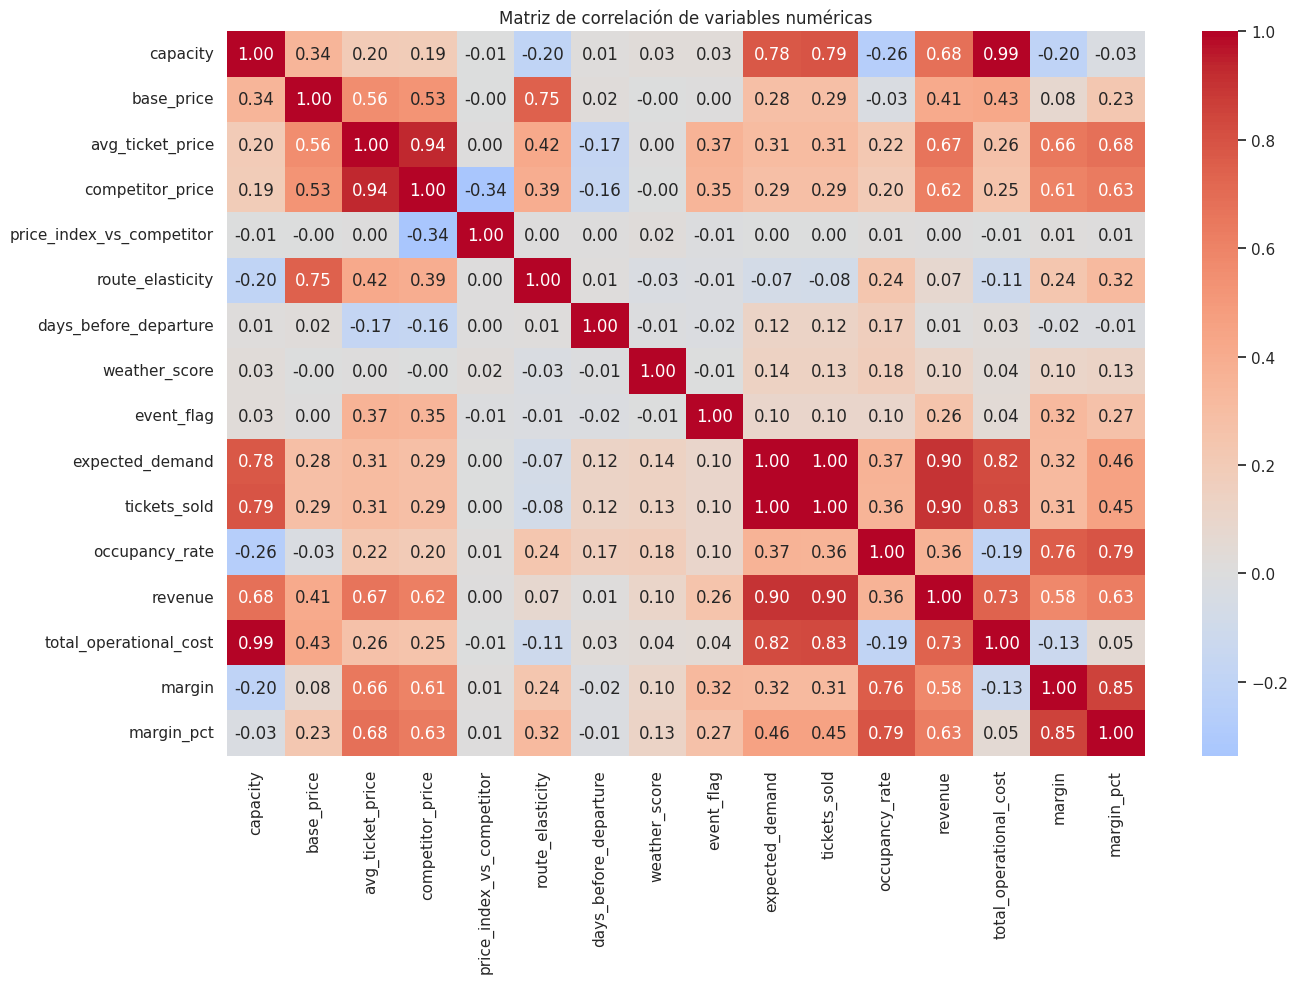

In [43]:
# ============================================================
# 34. MATRIZ DE CORRELACIÓN
# ============================================================

numeric_columns = [
    "capacity",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "route_elasticity",
    "days_before_departure",
    "weather_score",
    "event_flag",
    "expected_demand",
    "tickets_sold",
    "occupancy_rate",
    "revenue",
    "total_operational_cost",
    "margin",
    "margin_pct"
]

corr_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()

plt.savefig(f"{images_path}/20_correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [44]:
# ============================================================
# 35. ANÁLISIS SEGMENTADO: RUTA + TEMPORADA
# ============================================================

route_season_summary = (
    df
    .groupby(["route", "season"])
    .agg(
        trips=("trip_id", "count"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean"),
        avg_price_index=("price_index_vs_competitor", "mean")
    )
    .reset_index()
)

route_season_summary["season"] = pd.Categorical(
    route_season_summary["season"],
    categories=season_order,
    ordered=True
)

route_season_summary = route_season_summary.sort_values(
    ["route", "season"]
)

route_season_summary

,route,season,trips,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,avg_price_index
1,Denia-Formentera,Low,302,0.57,67.64,"3,251,384.64","-1,071,981.36",-0.37,1.02
2,Denia-Formentera,Shoulder,304,0.72,76.73,"4,729,087.81","284,709.81",0.03,1.03
0,Denia-Formentera,High,124,0.83,98.70,"2,848,611.07","1,009,322.07",0.34,1.03
4,Denia-Ibiza,Low,453,0.63,54.51,"5,386,623.54","-1,974,668.46",-0.41,1.03
5,Denia-Ibiza,Shoulder,456,0.77,61.86,"7,617,676.63","17,316.63",-0.03,1.03
3,Denia-Ibiza,High,186,0.86,81.06,"4,525,247.20","1,380,511.20",0.29,1.02
7,Denia-Mallorca,Low,302,0.46,59.53,"4,327,452.61","-3,195,487.39",-0.79,1.03
8,Denia-Mallorca,Shoulder,304,0.57,68.87,"6,147,638.21","-1,586,821.79",-0.30,1.03
6,Denia-Mallorca,High,124,0.62,89.48,"3,597,382.99","405,562.99",0.08,1.02
10,Ibiza-Mallorca,Low,453,0.54,45.70,"3,364,527.66","-2,499,264.34",-0.79,1.02


In [45]:
# ============================================================
# 36. SEGMENTOS CON ALTA OCUPACIÓN Y BUEN MARGEN
# ============================================================

strong_segments = route_season_summary[
    (route_season_summary["avg_occupancy"] >= 0.80) &
    (route_season_summary["avg_margin_pct"] >= 0.25)
].copy()

strong_segments = strong_segments.sort_values(
    ["avg_occupancy", "avg_margin_pct"],
    ascending=False
)

strong_segments

,route,season,trips,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,avg_price_index
3,Denia-Ibiza,High,186,0.86,81.06,"4,525,247.20","1,380,511.20",0.29,1.02
0,Denia-Formentera,High,124,0.83,98.70,"2,848,611.07","1,009,322.07",0.34,1.03


In [46]:
# ============================================================
# 37. SEGMENTOS CON ALTA OCUPACIÓN PERO MARGEN BAJO
# ============================================================

high_occupancy_low_margin = route_season_summary[
    (route_season_summary["avg_occupancy"] >= 0.80) &
    (route_season_summary["avg_margin_pct"] < 0.20)
].copy()

high_occupancy_low_margin = high_occupancy_low_margin.sort_values(
    ["avg_occupancy", "avg_margin_pct"],
    ascending=[False, True]
)

high_occupancy_low_margin

,route,season,trips,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,avg_price_index


In [47]:
# ============================================================
# 38. SEGMENTOS CON BAJA OCUPACIÓN
# ============================================================

low_occupancy_segments = route_season_summary[
    route_season_summary["avg_occupancy"] < 0.55
].copy()

low_occupancy_segments = low_occupancy_segments.sort_values(
    "avg_occupancy",
    ascending=True
)

low_occupancy_segments

,route,season,trips,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,avg_price_index
7,Denia-Mallorca,Low,302,0.46,59.53,"4,327,452.61","-3,195,487.39",-0.79,1.03
13,Valencia-Ibiza,Low,302,0.51,64.90,"6,112,379.46","-2,629,099.54",-0.48,1.02
16,Valencia-Mallorca,Low,453,0.52,57.68,"9,370,606.35","-5,047,477.65",-0.59,1.02
10,Ibiza-Mallorca,Low,453,0.54,45.70,"3,364,527.66","-2,499,264.34",-0.79,1.02


In [48]:
# ============================================================
# 39. DIAGNÓSTICO EJECUTIVO POR RUTA
# ============================================================

def route_diagnosis(row):
    if row["avg_occupancy"] >= 0.80 and row["avg_margin_pct"] >= 0.25:
        return "Strong route: protect and optimize pricing"
    elif row["avg_occupancy"] >= 0.80 and row["avg_margin_pct"] < 0.20:
        return "High demand but weak profitability"
    elif row["avg_occupancy"] < 0.55 and row["avg_margin_pct"] >= 0.25:
        return "Commercial demand opportunity"
    elif row["avg_occupancy"] < 0.55 and row["avg_margin_pct"] < 0.20:
        return "Route under pressure"
    else:
        return "Stable route: monitor"

route_diagnosis_table = route_summary.copy()

route_diagnosis_table["diagnosis"] = route_diagnosis_table.apply(route_diagnosis, axis=1)

route_diagnosis_table = route_diagnosis_table[[
    "route",
    "avg_occupancy",
    "avg_ticket_price",
    "total_revenue",
    "total_margin",
    "avg_margin_pct",
    "elasticity",
    "diagnosis"
]].sort_values("total_revenue", ascending=False)

route_diagnosis_table

,route,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,elasticity,diagnosis
5,Valencia-Mallorca,0.59,66.26,"30,124,521.77","-5,398,010.23",-0.29,-1.05,Stable route: monitor
4,Valencia-Ibiza,0.59,74.19,"19,932,754.20","-1,598,389.80",-0.19,-0.90,Stable route: monitor
1,Denia-Ibiza,0.73,62.08,"17,529,547.37","-576,840.63",-0.13,-0.85,Stable route: monitor
2,Denia-Mallorca,0.53,68.51,"14,072,473.81","-4,376,746.19",-0.44,-0.95,Route under pressure
0,Denia-Formentera,0.68,76.70,"10,829,083.52","222,050.52",-0.08,-0.75,Stable route: monitor
3,Ibiza-Mallorca,0.61,52.33,"10,510,459.10","-3,808,748.90",-0.47,-1.15,Stable route: monitor


In [49]:
# ============================================================
# 40. INSIGHTS AUTOMÁTICOS
# ============================================================

top_revenue_route = route_summary.sort_values("total_revenue", ascending=False).iloc[0]
top_margin_route = route_summary.sort_values("total_margin", ascending=False).iloc[0]
top_occupancy_route = route_summary.sort_values("avg_occupancy", ascending=False).iloc[0]
lowest_occupancy_route = route_summary.sort_values("avg_occupancy", ascending=True).iloc[0]
highest_margin_pct_route = route_summary.sort_values("avg_margin_pct", ascending=False).iloc[0]
lowest_margin_pct_route = route_summary.sort_values("avg_margin_pct", ascending=True).iloc[0]

print("INSIGHTS EJECUTIVOS")
print("-" * 60)

print(
    f"1. La ruta con mayor revenue total es {top_revenue_route['route']} "
    f"con {top_revenue_route['total_revenue']:,.2f} €."
)

print(
    f"2. La ruta con mayor margen total es {top_margin_route['route']} "
    f"con {top_margin_route['total_margin']:,.2f} €."
)

print(
    f"3. La ruta con mayor ocupación media es {top_occupancy_route['route']} "
    f"con una ocupación media del {top_occupancy_route['avg_occupancy']:.2%}."
)

print(
    f"4. La ruta con menor ocupación media es {lowest_occupancy_route['route']} "
    f"con una ocupación media del {lowest_occupancy_route['avg_occupancy']:.2%}."
)

print(
    f"5. La ruta con mayor margen porcentual medio es {highest_margin_pct_route['route']} "
    f"con un margen medio del {highest_margin_pct_route['avg_margin_pct']:.2%}."
)

print(
    f"6. La ruta con menor margen porcentual medio es {lowest_margin_pct_route['route']} "
    f"con un margen medio del {lowest_margin_pct_route['avg_margin_pct']:.2%}."
)

INSIGHTS EJECUTIVOS
------------------------------------------------------------
1. La ruta con mayor revenue total es Valencia-Mallorca con 30,124,521.77 €.
2. La ruta con mayor margen total es Denia-Formentera con 222,050.52 €.
3. La ruta con mayor ocupación media es Denia-Ibiza con una ocupación media del 72.70%.
4. La ruta con menor ocupación media es Denia-Mallorca con una ocupación media del 53.32%.
5. La ruta con mayor margen porcentual medio es Denia-Formentera con un margen medio del -8.30%.
6. La ruta con menor margen porcentual medio es Ibiza-Mallorca con un margen medio del -46.64%.


In [50]:
# ============================================================
# FUNCIÓN DE EXPORTACIÓN: CSV NORMAL + CSV EXCEL ES + XLSX
# ============================================================

from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

def export_table_files(dataframe, output_folder, file_name, sheet_name="Data"):
    """
    Exporta un DataFrame en tres formatos:

    1. CSV estándar para Python.
    2. CSV compatible con Excel España: separador ; y decimal ,
    3. XLSX con formato numérico.
    """

    os.makedirs(output_folder, exist_ok=True)

    csv_path = f"{output_folder}/{file_name}.csv"
    csv_excel_es_path = f"{output_folder}/{file_name}_excel_es.csv"
    xlsx_path = f"{output_folder}/{file_name}.xlsx"

    # Copia para exportación regional
    df_export = dataframe.copy()

    # Formateo de fechas para CSV regional
    for col in df_export.columns:
        if pd.api.types.is_datetime64_any_dtype(df_export[col]):
            df_export[col] = df_export[col].dt.strftime("%d/%m/%Y %H:%M")

    # CSV estándar
    dataframe.to_csv(csv_path, index=False, encoding="utf-8-sig")

    # CSV compatible con Excel España
    df_export.to_csv(
        csv_excel_es_path,
        index=False,
        sep=";",
        decimal=",",
        encoding="utf-8-sig"
    )

    # Excel XLSX
    safe_sheet_name = sheet_name[:31]

    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        dataframe.to_excel(writer, index=False, sheet_name=safe_sheet_name)

        workbook = writer.book
        worksheet = writer.sheets[safe_sheet_name]

        # Congelar encabezado
        worksheet.freeze_panes = "A2"

        # Filtro automático
        worksheet.auto_filter.ref = worksheet.dimensions

        # Estilo encabezados
        for cell in worksheet[1]:
            cell.font = Font(bold=True)

        # Formato de columnas
        for col_idx, col_name in enumerate(dataframe.columns, start=1):
            column_letter = get_column_letter(col_idx)

            if pd.api.types.is_float_dtype(dataframe[col_name]):
                if col_name in ["occupancy_rate", "margin_pct", "avg_margin_pct", "price_gap_pct"]:
                    number_format = "0.00%"
                else:
                    number_format = "0.00"

                for cell in worksheet[column_letter][1:]:
                    cell.number_format = number_format

            elif pd.api.types.is_integer_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "0"

            elif pd.api.types.is_datetime64_any_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "DD/MM/YYYY HH:MM"

        # Ajuste de ancho de columnas
        for column_cells in worksheet.columns:
            max_length = 0
            column_letter = get_column_letter(column_cells[0].column)

            for cell in column_cells:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))

            adjusted_width = min(max_length + 2, 35)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"Exportado: {file_name}")
    print(f"- {csv_path}")
    print(f"- {csv_excel_es_path}")
    print(f"- {xlsx_path}")

In [51]:
# ============================================================
# 41. GUARDADO DE TABLAS DE ANÁLISIS
# ============================================================

route_summary.to_csv(f"{reports_path}/route_summary_pricing.csv", index=False)
season_summary.to_csv(f"{reports_path}/season_summary_pricing.csv", index=False)
monthly_summary.to_csv(f"{reports_path}/monthly_summary_pricing.csv", index=False)
day_summary.to_csv(f"{reports_path}/day_summary_pricing.csv", index=False)
booking_summary.to_csv(f"{reports_path}/booking_summary_pricing.csv", index=False)
competitor_summary.to_csv(f"{reports_path}/competitor_summary_pricing.csv", index=False)
route_season_summary.to_csv(f"{reports_path}/route_season_summary_pricing.csv", index=False)
route_diagnosis_table.to_csv(f"{reports_path}/route_diagnosis_pricing.csv", index=False)

print("Tablas de análisis guardadas correctamente en:")
print(reports_path)

Tablas de análisis guardadas correctamente en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports


In [52]:
# ============================================================
# 42. RESUMEN EJECUTIVO EN MARKDOWN
# ============================================================

executive_summary = f"""
# Executive Summary — Exploratory Pricing Analysis

## Project context

This analysis explores pricing, demand, occupancy, revenue and profitability patterns for a simulated ferry operator: Levante Ferries.

## General KPIs

- Total trips analyzed: {total_trips:,.0f}
- Tickets sold: {total_tickets:,.0f}
- Total revenue: {total_revenue:,.2f} €
- Total operational cost: {total_cost:,.2f} €
- Total margin: {total_margin:,.2f} €
- Average occupancy: {avg_occupancy:.2%}
- Average ticket price: {avg_ticket_price:.2f} €
- Average margin percentage: {avg_margin_pct:.2%}

## Key findings

1. The route with the highest total revenue is **{top_revenue_route['route']}**.
2. The route with the highest total margin is **{top_margin_route['route']}**.
3. The route with the highest average occupancy is **{top_occupancy_route['route']}**.
4. The route with the lowest average occupancy is **{lowest_occupancy_route['route']}**.
5. The route with the highest average margin percentage is **{highest_margin_pct_route['route']}**.
6. The route with the lowest average margin percentage is **{lowest_margin_pct_route['route']}**.

## Business interpretation

The exploratory analysis shows that pricing decisions should not be based only on revenue.
A route may generate high sales but still present weak profitability due to operational costs, insufficient pricing or capacity constraints.

The most relevant dimensions for future pricing optimization are:

- Route.
- Season.
- Booking window.
- Occupancy level.
- Margin percentage.
- Price positioning versus competitors.
- Estimated price elasticity.

## Next step

The next notebook will focus on **price elasticity analysis**, estimating how sensitive each route is to price changes and identifying where price increases or promotional actions may be more effective.
"""

summary_path = f"{reports_path}/executive_summary_notebook_02.md"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(executive_summary)

print("Resumen ejecutivo guardado en:")
print(summary_path)

Resumen ejecutivo guardado en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports/executive_summary_notebook_02.md


In [53]:
# ============================================================
# FUNCIÓN DE EXPORTACIÓN: CSV NORMAL + CSV EXCEL ES + XLSX
# ============================================================

from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

def export_table_files(dataframe, output_folder, file_name, sheet_name="Data"):
    """
    Exporta un DataFrame en tres formatos:

    1. CSV estándar para Python.
    2. CSV compatible con Excel España: separador ; y decimal ,
    3. XLSX con formato numérico.
    """

    os.makedirs(output_folder, exist_ok=True)

    csv_path = f"{output_folder}/{file_name}.csv"
    csv_excel_es_path = f"{output_folder}/{file_name}_excel_es.csv"
    xlsx_path = f"{output_folder}/{file_name}.xlsx"

    # Copia para exportación regional
    df_export = dataframe.copy()

    # Formateo de fechas para CSV regional
    for col in df_export.columns:
        if pd.api.types.is_datetime64_any_dtype(df_export[col]):
            df_export[col] = df_export[col].dt.strftime("%d/%m/%Y %H:%M")

    # CSV estándar
    dataframe.to_csv(csv_path, index=False, encoding="utf-8-sig")

    # CSV compatible con Excel España
    df_export.to_csv(
        csv_excel_es_path,
        index=False,
        sep=";",
        decimal=",",
        encoding="utf-8-sig"
    )

    # Excel XLSX
    safe_sheet_name = sheet_name[:31]

    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        dataframe.to_excel(writer, index=False, sheet_name=safe_sheet_name)

        workbook = writer.book
        worksheet = writer.sheets[safe_sheet_name]

        # Congelar encabezado
        worksheet.freeze_panes = "A2"

        # Filtro automático
        worksheet.auto_filter.ref = worksheet.dimensions

        # Estilo encabezados
        for cell in worksheet[1]:
            cell.font = Font(bold=True)

        # Formato de columnas
        for col_idx, col_name in enumerate(dataframe.columns, start=1):
            column_letter = get_column_letter(col_idx)

            if pd.api.types.is_float_dtype(dataframe[col_name]):
                if col_name in ["occupancy_rate", "margin_pct", "avg_margin_pct", "price_gap_pct"]:
                    number_format = "0.00%"
                else:
                    number_format = "0.00"

                for cell in worksheet[column_letter][1:]:
                    cell.number_format = number_format

            elif pd.api.types.is_integer_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "0"

            elif pd.api.types.is_datetime64_any_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "DD/MM/YYYY HH:MM"

        # Ajuste de ancho de columnas
        for column_cells in worksheet.columns:
            max_length = 0
            column_letter = get_column_letter(column_cells[0].column)

            for cell in column_cells:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))

            adjusted_width = min(max_length + 2, 35)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"Exportado: {file_name}")
    print(f"- {csv_path}")
    print(f"- {csv_excel_es_path}")
    print(f"- {xlsx_path}")

In [54]:
# ============================================================
# 43. ARCHIVOS GENERADOS
# ============================================================

print("Imágenes generadas:")
for file in sorted(os.listdir(images_path)):
    if file.endswith(".png"):
        print("-", file)

print("\nReportes generados:")
for file in sorted(os.listdir(reports_path)):
    if file.endswith(".csv") or file.endswith(".md"):
        print("-", file)

Imágenes generadas:
- 01_revenue_by_route.png
- 02_occupancy_by_route.png
- 03_margin_by_route.png
- 04_margin_pct_by_route.png
- 05_revenue_by_season.png
- 06_price_distribution_by_season.png
- 07_occupancy_distribution_by_season.png
- 08_monthly_revenue_trend.png
- 09_monthly_occupancy_trend.png
- 10_revenue_by_day_of_week.png
- 11_occupancy_by_departure_hour.png
- 12_price_by_booking_window.png
- 13_price_vs_occupancy.png
- 14_occupancy_vs_margin_pct.png
- 14_price_vs_occupancy_season_lmplot.png
- 15_heatmap_route_season_revenue.png
- 15_occupancy_vs_margin_pct_season_lmplot.png
- 16_heatmap_route_season_margin.png
- 16_heatmap_route_season_occupancy.png
- 17_price_index_vs_competitor.png
- 18_pricing_opportunity_distribution.png
- 19_pricing_opportunity_by_route.png
- 20_correlation_matrix.png
- 21_elasticity_by_route.png
- 22_price_vs_demand_by_route.png
- 23_elasticity_vs_occupancy_diagnosis.png
- 24_heatmap_route_season_elasticity.png
- 25_revenue_scenario_simulation_by_route.pn

## Conclusiones del Notebook 2

En este notebook se ha realizado un análisis exploratorio del dataset de pricing generado en el Notebook 1.

El análisis ha permitido estudiar el comportamiento de las rutas desde diferentes perspectivas:

- Revenue.
- Ocupación.
- Precio medio.
- Margen absoluto.
- Margen porcentual.
- Temporada.
- Día de la semana.
- Hora de salida.
- Ventana de reserva.
- Comparación con precio de competidor.
- Oportunidades de pricing.

Una de las principales conclusiones es que las decisiones de pricing no deben basarse únicamente en el revenue total. Es necesario cruzar ingresos con ocupación, margen, costes, elasticidad y posición competitiva.

También se han identificado segmentos con alta ocupación, rutas con posible presión de margen y rutas donde podría existir oportunidad comercial o promocional.

Este análisis exploratorio prepara la base para el siguiente notebook, donde se estudiará la elasticidad precio-demanda para entender cómo responde la demanda ante cambios de precio.